# A-level humanities: History, Geography and Philosophy against GCSE humanities

The same question as for English, the sciences and languages, now for the humanities. We model A-level History, Geography and Philosophy value added together against GCSE humanities value added (`HUMVAMEA_PTQ_EE`, the humanities element of the GCSE value-added measure).

The model is the correlated-residuals model from the science notebook:

- a latent school-level **GCSE humanities VA**, measured with known error;
- **subject-specific** intercept and slope on that GCSE VA;
- **correlated school residuals** across the three subjects, with an LKJ prior on the correlation matrix.

The three subjects are very unevenly sized. History and Geography are offered by well over a thousand schools each, and most schools that offer one offer the other. Philosophy (`Logic/ Philosophy` in the data) is offered by only about a hundred, but nearly all of those also have History and Geography, so its correlations with the other two are estimated from a reasonable number of schools. Whether the extra shared-school-effect model is worth fitting depends on how well those correlations come out, so we look at that before deciding.

In [1]:
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt

%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v6.3.1


## Data

We reshape `all-value-add-errors.csv` to long format: one row per school × subject, keeping the published confidence interval and entries. Schools need GCSE humanities VA and at least one of the three A-level VA scores. The standard error is `(upper - lower) / (2 * 1.96)`.

First, for context, the number of schools that have both the A-level score and GCSE humanities VA for each humanities or humanities-adjacent A-level. History, Geography and Philosophy are the three we model; the others are shown so the size of the Philosophy sample can be judged against its neighbours. Philosophy is the column `Logic/ Philosophy`.

In [2]:
raw = pd.read_csv("data/all-value-add-errors.csv")

gcse_ok = raw[["HUMVAMEA_PTQ_EE", "HUMVAMEA_PTQ_EE lower", "HUMVAMEA_PTQ_EE upper", "HUMVAMEA_PTQ_EE pupils"]].notna().all(axis=1)
candidates = ["History", "Geography", "Logic/ Philosophy", "Religious Studies", "Government & Politics", "Sociology",
              "Economics", "Psychology", "Law", "Classical Civilisation", "History of Art", "Ancient History"]
rows = []
for name in candidates:
    p = f"A-level {name}"
    ok = raw[[f"{p} VA", f"{p} VA lower", f"{p} VA upper", f"{p} entries"]].notna().all(axis=1)
    rows.append({"subject": name, "schools_with_gcse_humanities": int((ok & gcse_ok).sum()),
                 "median_entries": raw.loc[ok & gcse_ok, f"{p} entries"].median()})
ranking = pd.DataFrame(rows).sort_values("schools_with_gcse_humanities", ascending=False).reset_index(drop=True)
print(f"{int(gcse_ok.sum())} schools have GCSE humanities VA")
ranking

1845 schools have GCSE humanities VA


,subject,schools_with_gcse_humanities,median_entries
0,Psychology,1592,23.0
1,History,1362,14.0
2,Sociology,1282,16.5
3,Geography,1148,13.0
4,Economics,934,19.0
5,Government & Politics,742,12.0
6,Religious Studies,679,10.0
7,Law,278,15.0
8,Logic/ Philosophy,100,10.0
9,Classical Civilisation,94,10.0


In [3]:
subjects = ["History", "Geography", "Philosophy"]
column_name = {"History": "History", "Geography": "Geography", "Philosophy": "Logic/ Philosophy"}
school_cols = ["URN", "HUMVAMEA_PTQ_EE", "HUMVAMEA_PTQ_EE lower", "HUMVAMEA_PTQ_EE upper", "HUMVAMEA_PTQ_EE pupils"]

schools = (
    raw[school_cols]
    .rename(columns={"HUMVAMEA_PTQ_EE": "gcse_va", "HUMVAMEA_PTQ_EE lower": "gcse_lower",
                     "HUMVAMEA_PTQ_EE upper": "gcse_upper", "HUMVAMEA_PTQ_EE pupils": "gcse_pupils"})
    .dropna()
)

frames = []
for subject in subjects:
    prefix = f"A-level {column_name[subject]}"
    sub = raw[["URN", f"{prefix} VA", f"{prefix} VA lower", f"{prefix} VA upper", f"{prefix} entries"]].dropna()
    sub.columns = ["URN", "alevel_va", "alevel_lower", "alevel_upper", "alevel_entries"]
    sub["subject"] = subject
    frames.append(sub)
long = pd.concat(frames)

Z_95 = 1.96
long["alevel_se"] = (long["alevel_upper"] - long["alevel_lower"]) / (2 * Z_95)
schools["gcse_se"] = (schools["gcse_upper"] - schools["gcse_lower"]) / (2 * Z_95)

long = long.merge(schools[["URN"]], on="URN", how="inner")
schools = schools[schools["URN"].isin(long["URN"])].reset_index(drop=True)

school_idx = pd.Series(np.arange(len(schools)), index=schools["URN"])
long["school_idx"] = long["URN"].map(school_idx).to_numpy()
long["subject_idx"] = long["subject"].map({s: k for k, s in enumerate(subjects)}).to_numpy()
long = long.reset_index(drop=True)

print(f"{len(schools)} schools, {len(long)} school-subject observations")
print("subjects per school:", long.groupby("URN")["subject"].nunique().value_counts().sort_index().to_dict())

presence = long.pivot(index="URN", columns="subject", values="alevel_va")[subjects].notna().astype(int)
overlap = presence.T @ presence
print("\nSchools with each pair of subjects (diagonal = schools with that subject):")
display(overlap)
long.groupby("subject")[["alevel_va", "alevel_se", "alevel_entries"]].agg(["mean", "std", "median"]).round(3)

1471 schools, 2610 school-subject observations
subjects per school: {1: 417, 2: 969, 3: 85}

Schools with each pair of subjects (diagonal = schools with that subject):


subject,History,Geography,Philosophy
subject,,,
History,1362,1040,95
Geography,1040,1148,89
Philosophy,95,89,100


alevel_va               alevel_se               alevel_entries  \
                mean    std median      mean    std median           mean   
subject                                                                     
Geography     -0.033  0.403 -0.010     0.267  0.069  0.263         15.793   
History       -0.011  0.389  0.020     0.245  0.063  0.240         16.749   
Philosophy    -0.009  0.460 -0.015     0.307  0.059  0.311         11.700   

                          
              std median  
subject                   
Geography   9.562   13.0  
History     9.669   14.0  
Philosophy  5.171   10.0

### Checking the confidence-interval formula

DfE's interval is $\pm 1.96\,\sigma_{national}/\sqrt{n}$, so $se\sqrt{n}$ should be constant within each measure.

In [4]:
print((long["alevel_se"] * np.sqrt(long["alevel_entries"])).groupby(long["subject"]).agg(["mean", "std"]).round(3))
print("GCSE humanities:", (schools["gcse_se"] * np.sqrt(schools["gcse_pupils"])).agg(["mean", "std"]).round(3).to_dict())

             mean    std
subject                 
Geography   0.949  0.004
History     0.903  0.004
Philosophy  0.989  0.004
GCSE humanities: {'mean': 1.777, 'std': 0.014}


Each measure has its own near-constant national SD (0.90, 0.95 and 0.99 for History, Geography and Philosophy, and 1.78 for GCSE humanities), so the standard errors are pure sampling noise.

## Exploratory look

Left: each subject against GCSE humanities VA. Right: raw pairwise correlations between the A-level VA scores, using the schools that have each pair (1,040 for History-Geography, 95 for History-Philosophy, 89 for Geography-Philosophy; 85 schools have all three).

/tmp/ipykernel_115664/217549454.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


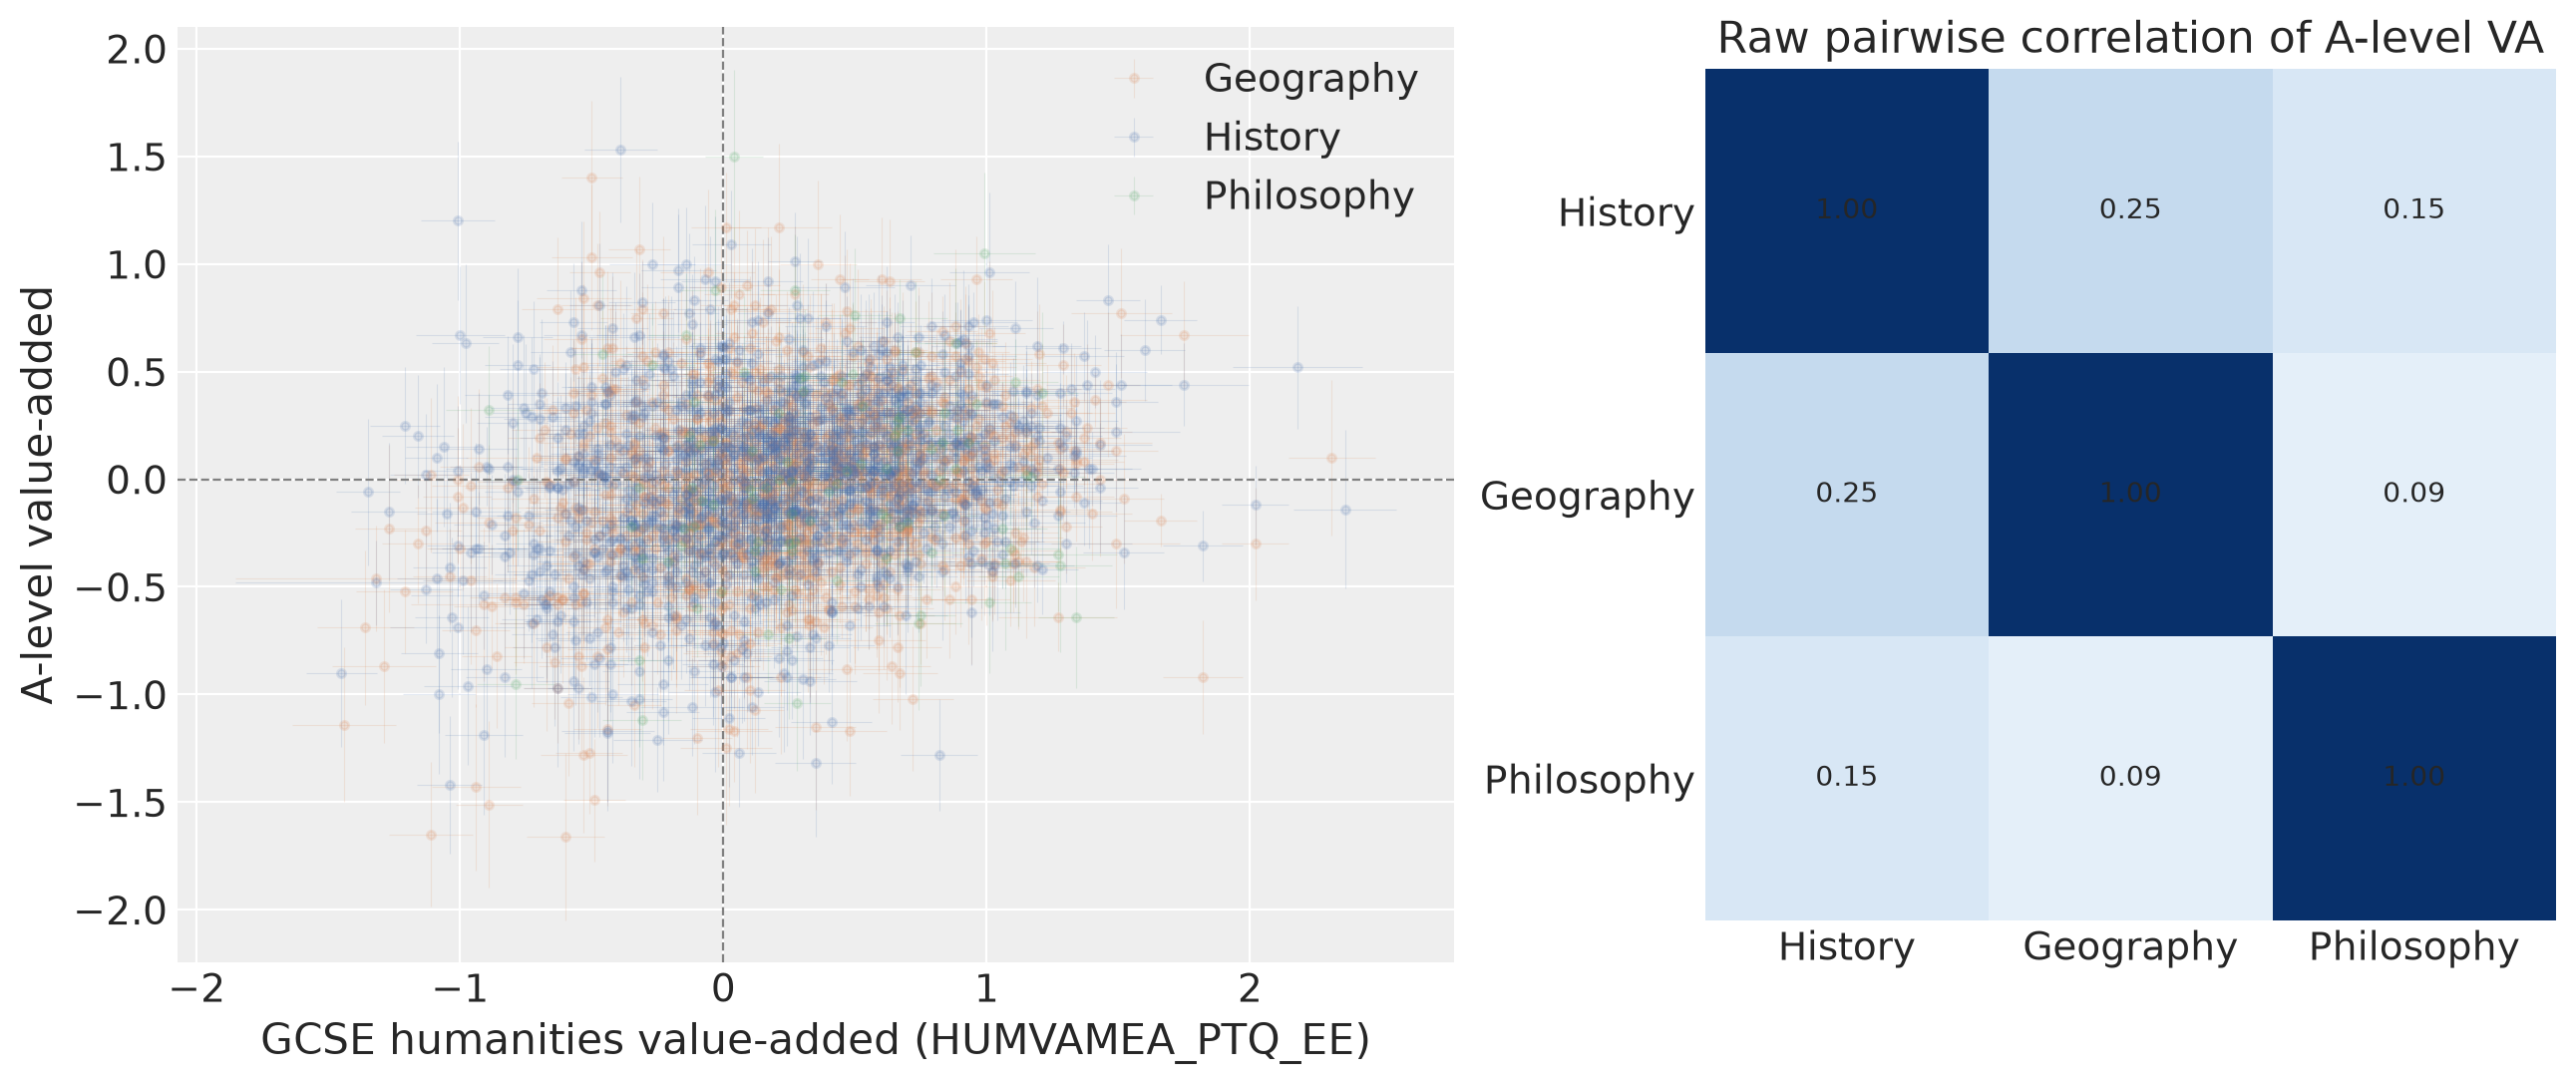

In [5]:
colors = {"History": "#4C72B0", "Geography": "#DD8452", "Philosophy": "#55A868"}
plot_df = long.merge(schools[["URN", "gcse_va", "gcse_se"]], on="URN")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [1.5, 1]})
for subject, g in plot_df.groupby("subject"):
    axes[0].errorbar(g["gcse_va"], g["alevel_va"], xerr=g["gcse_se"], yerr=g["alevel_se"], fmt="o",
                     color=colors[subject], ecolor=colors[subject], alpha=0.15, markersize=3, elinewidth=0.4, label=subject)
axes[0].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].axvline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("GCSE humanities value-added (HUMVAMEA_PTQ_EE)")
axes[0].set_ylabel("A-level value-added")
axes[0].legend()

wide = long.pivot(index="URN", columns="subject", values="alevel_va")[subjects]
raw_corr = wide.corr(min_periods=10)
im = axes[1].imshow(raw_corr, vmin=0, vmax=1, cmap="Blues")
axes[1].set_xticks(range(3), subjects)
axes[1].set_yticks(range(3), subjects)
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f"{raw_corr.iloc[i, j]:.2f}", ha="center", va="center")
axes[1].set_title("Raw pairwise correlation of A-level VA")
axes[1].grid(False)
plt.tight_layout()
plt.show()

The raw correlations are low (History-Geography 0.25, History-Philosophy 0.15, Geography-Philosophy 0.09) because each A-level score carries a lot of sampling noise (standard error 0.25-0.31 against a spread of 0.39-0.46). The model handles that. The Philosophy pairs rest on about 90 schools.

## Model

For school $i$ with true GCSE VA $x_i$, and subject $s \in \{\text{History}, \text{Geography}, \text{Philosophy}\}$:

$$
\begin{aligned}
x_i &\sim \text{Normal}(\mu_x, \tau_x), \qquad x_i^{obs} \sim \text{Normal}(x_i, \sigma^x_i) \\
y_{is} &= \alpha_s + \beta_s x_i + \epsilon_{is}, \qquad y_{is}^{obs} \sim \text{Normal}(y_{is}, \sigma^y_{is}) \\
\boldsymbol{\epsilon}_i &\sim \text{MultivariateNormal}(0, \Sigma), \qquad \Sigma = \text{diag}(\tau)\, R\, \text{diag}(\tau), \quad R \sim \text{LKJ}(\eta = 2)
\end{aligned}
$$

$R$ is the $3\times3$ correlation matrix of a school's true subject effects once the GCSE effect is removed. Schools with fewer than three subjects contribute through the marginal distribution of the subjects they have. Each subject's $\alpha_s, \beta_s$ gets its own weakly informative prior. The residuals are non-centered via the Cholesky factor of $\Sigma$.

In [6]:
n_schools = len(schools)
gcse_obs = schools["gcse_va"].to_numpy()
gcse_se = schools["gcse_se"].to_numpy()
y_obs = long["alevel_va"].to_numpy()
y_se = long["alevel_se"].to_numpy()
s_idx = long["school_idx"].to_numpy()
subj_idx = long["subject_idx"].to_numpy()
n_subjects = len(subjects)

with pm.Model(coords={"subject": subjects}) as corr_model:
    mu_x = pm.Normal("mu_x", 0, 1)
    tau_x = pm.HalfNormal("tau_x", 1)
    x_raw = pm.Normal("x_raw", 0, 1, shape=n_schools)
    x_true = mu_x + tau_x * x_raw

    alpha = pm.Normal("alpha", 0, 1, dims="subject")
    beta = pm.Normal("beta", 0, 1, dims="subject")

    chol, corr, stds = pm.LKJCholeskyCov(
        "chol_cov", n=n_subjects, eta=2.0, sd_dist=pm.HalfNormal.dist(1.0, shape=n_subjects), compute_corr=True
    )
    z = pm.Normal("z", 0, 1, shape=(n_schools, n_subjects))
    eps_all = pt.dot(z, chol.T)
    eps = eps_all[s_idx, subj_idx]

    y_true = alpha[subj_idx] + beta[subj_idx] * x_true[s_idx] + eps

    pm.Normal("gcse_obs", mu=x_true, sigma=gcse_se, observed=gcse_obs)
    pm.Normal("alevel_obs", mu=y_true, sigma=y_se, observed=y_obs)

### Prior predictive check

Sampling: [alevel_obs, alpha, beta, chol_cov, gcse_obs, mu_x, tau_x, x_raw, z]


/tmp/ipykernel_115664/1462487874.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


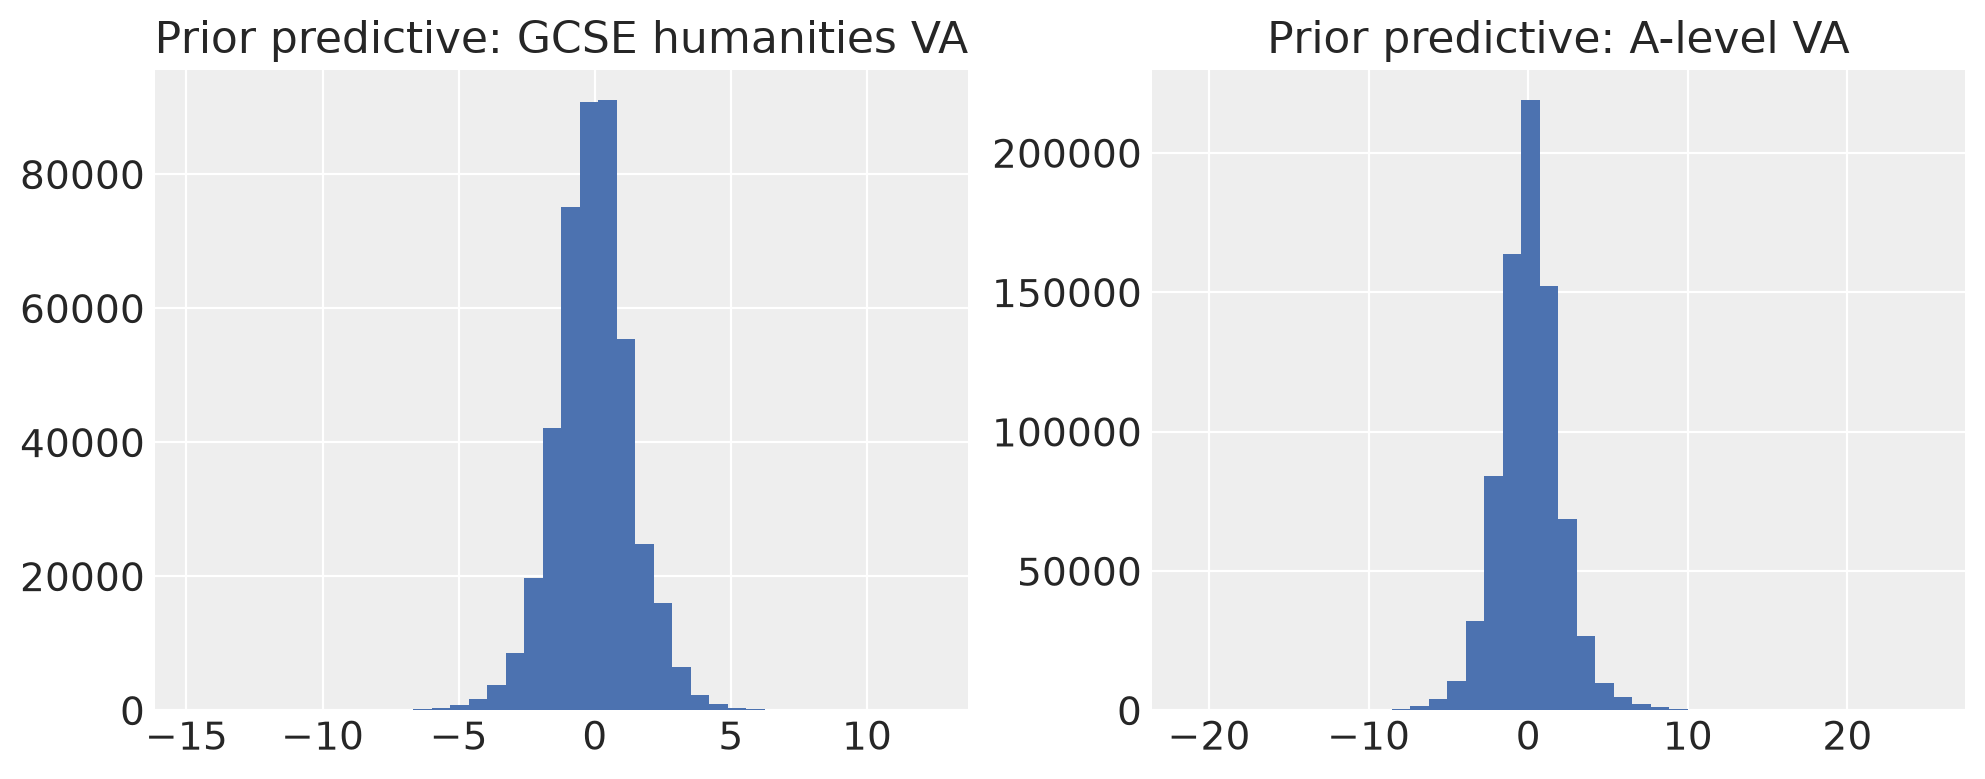

In [7]:
with corr_model:
    prior = pm.sample_prior_predictive(draws=300, random_seed=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(prior.prior_predictive["gcse_obs"].to_numpy().ravel(), bins=40, color="#4C72B0")
axes[0].set_title("Prior predictive: GCSE humanities VA")
axes[1].hist(prior.prior_predictive["alevel_obs"].to_numpy().ravel(), bins=40, color="#4C72B0")
axes[1].set_title("Prior predictive: A-level VA")
plt.tight_layout()
plt.show()
del prior

### Fit

In [8]:
with corr_model:
    idata_corr = pm.sample(draws=1000, tune=2000, chains=4, target_accept=0.99,
                           random_seed=RANDOM_SEED, progressbar=False)
    idata_corr.update(pm.sample_posterior_predictive(idata_corr, random_seed=RANDOM_SEED, progressbar=False))

NUTS[nutpie]: [mu_x, tau_x, x_raw, alpha, beta, chol_cov, z]


Sampling: [alevel_obs, gcse_obs]


### Diagnostics

In [9]:
print(f"divergences = {int(idata_corr.sample_stats['diverging'].sum())}")
az.summary(idata_corr, var_names=["alpha", "beta", "chol_cov_stds", "chol_cov_corr", "mu_x", "tau_x"], round_to=3)

divergences = 0


/opt/conda/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/opt/conda/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:313: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha[History],-0.048,0.011,-0.065,-0.031,2651.033,2930.081,1.000,0.000,0.000
alpha[Geography],-0.070,0.013,-0.090,-0.050,3384.911,3054.416,1.001,0.000,0.000
alpha[Philosophy],-0.065,0.059,-0.158,0.030,2418.974,2598.455,1.002,0.001,0.001
beta[History],0.186,0.020,0.155,0.218,2242.303,2506.766,1.000,0.000,0.000
beta[Geography],0.168,0.022,0.132,0.203,2012.122,2785.223,1.001,0.000,0.000
beta[Philosophy],0.111,0.101,-0.050,0.273,2413.114,2745.529,1.001,0.002,0.002
chol_cov_stds[0],0.265,0.010,0.250,0.280,1906.055,2850.284,1.000,0.000,0.000
chol_cov_stds[1],0.259,0.011,0.242,0.276,2046.269,2892.873,1.001,0.000,0.000
chol_cov_stds[2],0.324,0.045,0.254,0.397,2281.558,2508.522,1.000,0.001,0.001
"chol_cov_corr[0, 0]",1.000,0.000,1.000,1.000,4000.000,4000.000,NaN,0.000,NaN


## What the pooling shows

### How related are a school's effects across the three humanities?

Posterior of the three pairwise correlations between a school's true subject effects, after removing the GCSE effect.

History-Geography  mean=0.390, 89% interval [0.300, 0.475]
History-Philosophy mean=0.288, 89% interval [0.005, 0.556]
Geography-Philosophy mean=0.094, 89% interval [-0.219, 0.408]


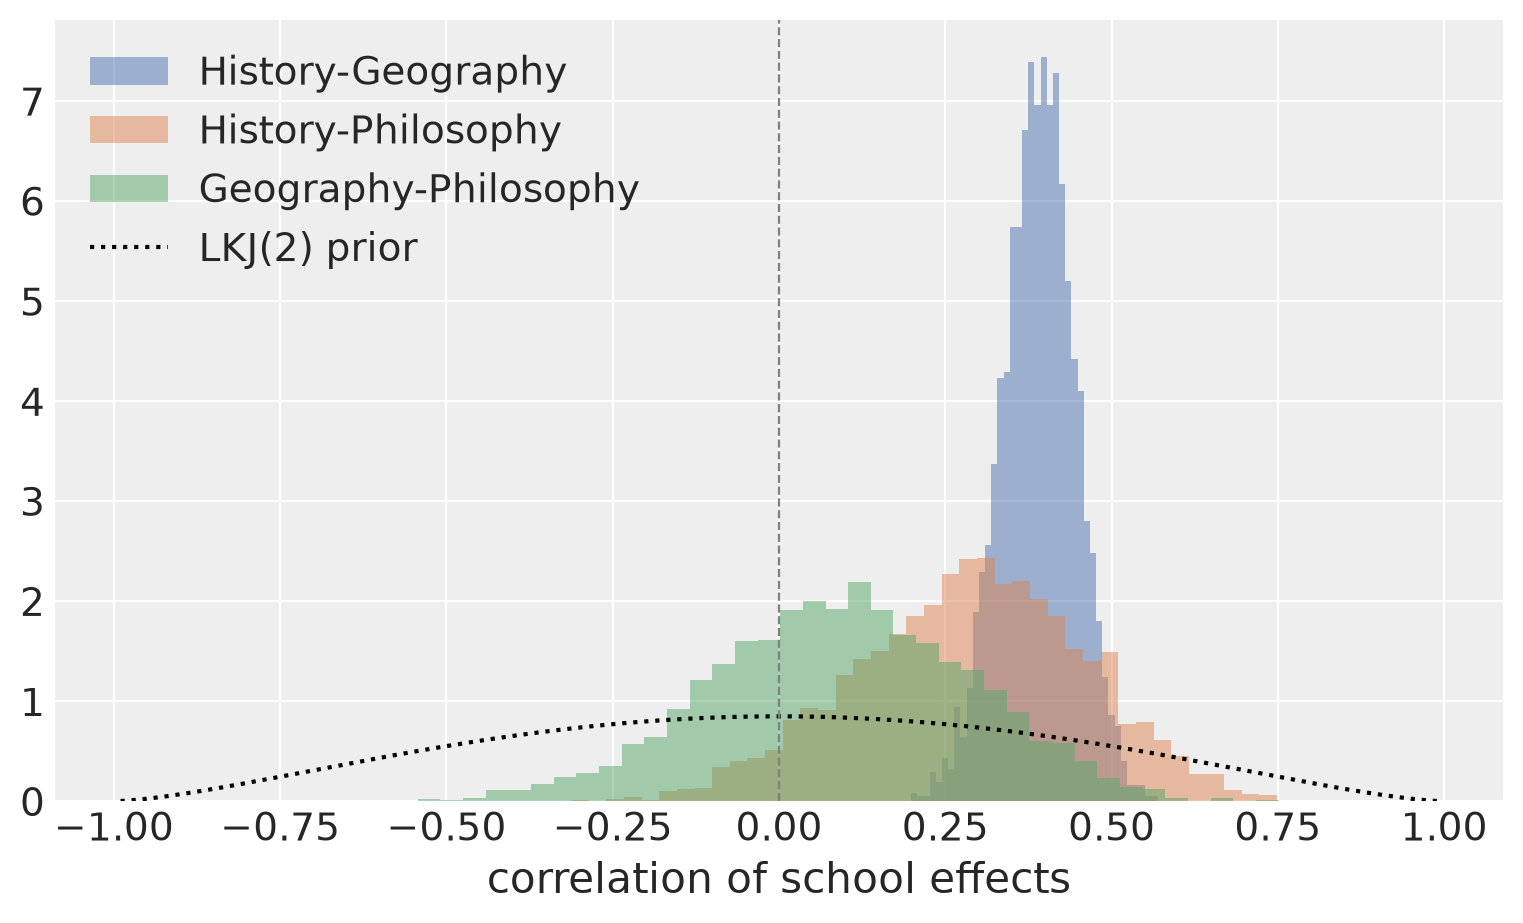

In [10]:
post = idata_corr.posterior
corr_s = post["chol_cov_corr"].to_numpy()

def summarise(x):
    lo, hi = np.percentile(x, [5.5, 94.5])
    return f"mean={x.mean():.3f}, 89% interval [{lo:.3f}, {hi:.3f}]"

pairs = [(0, 1), (0, 2), (1, 2)]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
pair_colors = ["#4C72B0", "#DD8452", "#55A868"]
for (i, j), c in zip(pairs, pair_colors):
    r = corr_s[..., i, j].ravel()
    ax.hist(r, bins=40, density=True, alpha=0.5, color=c, label=f"{subjects[i]}-{subjects[j]}")
    print(f"{subjects[i]}-{subjects[j]:10s} {summarise(r)}")
r_grid = np.linspace(-0.99, 0.99, 400)
prior_density = (1 - r_grid**2) ** 1.5
prior_density /= np.trapezoid(prior_density, r_grid)
ax.plot(r_grid, prior_density, color="black", linestyle=":", linewidth=1.5, label="LKJ(2) prior")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("correlation of school effects")
ax.legend()
plt.show()

### Slopes by subject

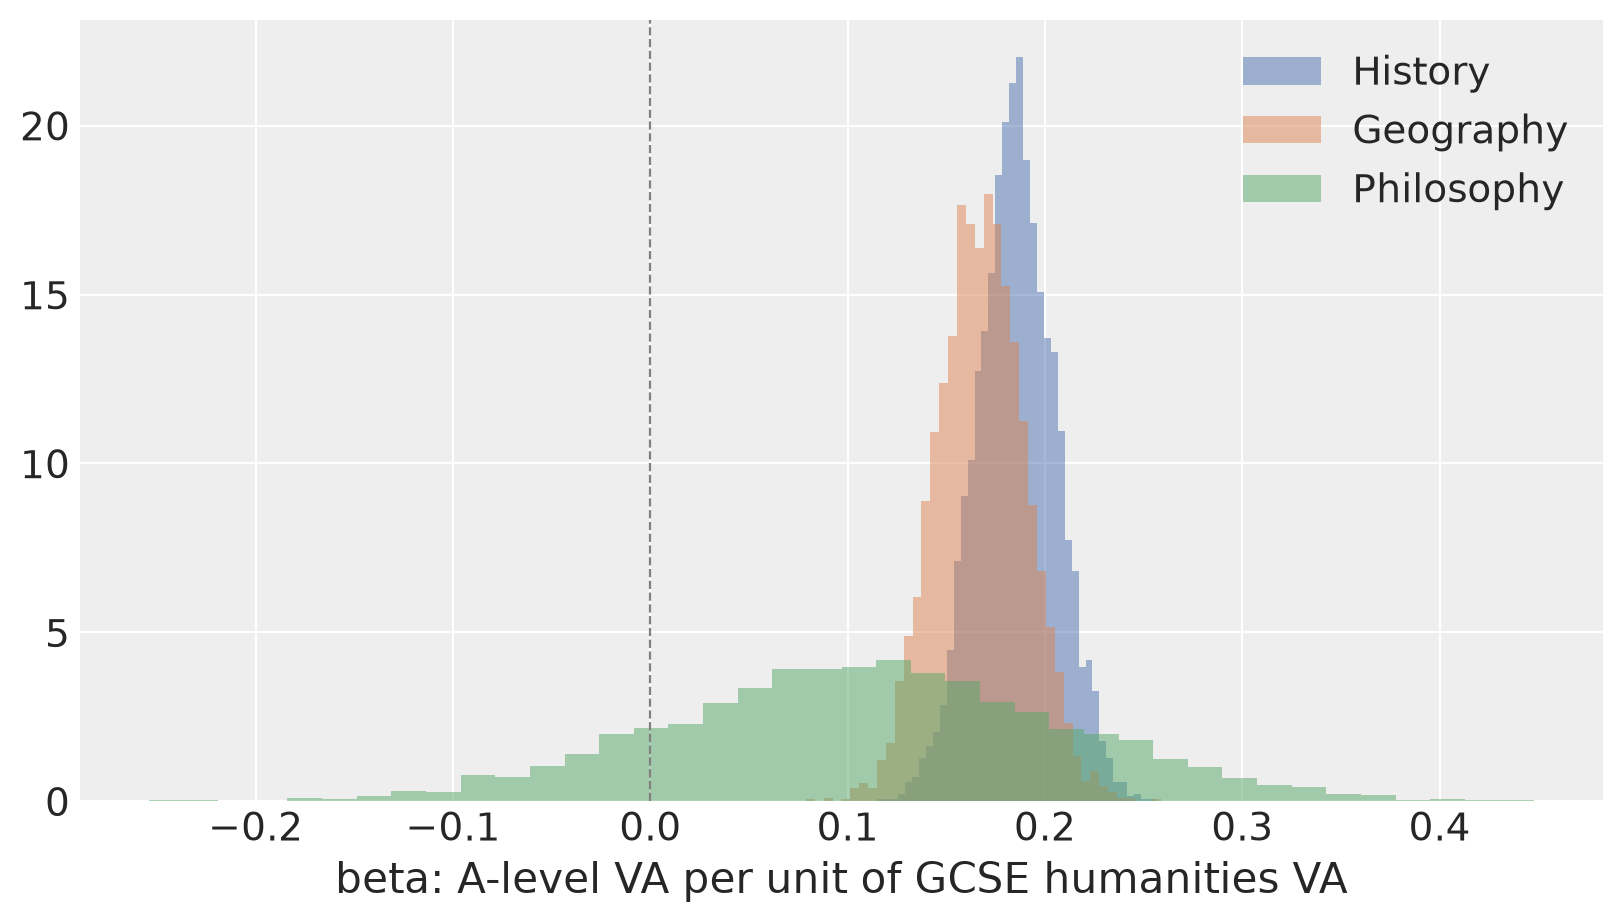

beta History    mean=0.186, 89% interval [0.155, 0.218]
beta Geography  mean=0.168, 89% interval [0.132, 0.203]
beta Philosophy mean=0.111, 89% interval [-0.050, 0.273]


In [11]:
beta_post = post["beta"]

fig, ax = plt.subplots(figsize=(8, 4.5))
for subject in subjects:
    ax.hist(beta_post.sel(subject=subject).to_numpy().ravel(), bins=40, density=True, alpha=0.5,
            color=colors[subject], label=subject)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("beta: A-level VA per unit of GCSE humanities VA")
ax.legend()
plt.show()

for subject in subjects:
    print(f"beta {subject:10s}", summarise(beta_post.sel(subject=subject).to_numpy().ravel()))

## Goodness of fit

Bayesian $R^2$ on the latent scale, per subject: the variance of the structural part $\alpha_s + \beta_s x_i$ relative to that variance plus the residual variance $\tau_s^2$.

In [12]:
x_post = post["mu_x"].to_numpy()[..., None] + post["tau_x"].to_numpy()[..., None] * post["x_raw"].to_numpy()
stds_post = post["chol_cov_stds"].to_numpy()
r2 = {}
for k, name in enumerate(subjects):
    sch = s_idx[subj_idx == k]
    fit = post["alpha"].sel(subject=name).to_numpy()[..., None] + post["beta"].sel(subject=name).to_numpy()[..., None] * x_post[..., sch]
    var_fit = fit.var(axis=-1)
    r2[name] = (var_fit / (var_fit + stds_post[..., k] ** 2)).ravel()
    print(f"{name}: R² from GCSE humanities VA: {summarise(r2[name])}")

History: R² from GCSE humanities VA: mean=0.119, 89% interval [0.084, 0.158]
Geography: R² from GCSE humanities VA: mean=0.100, 89% interval [0.063, 0.143]
Philosophy: R² from GCSE humanities VA: mean=0.044, 89% interval [0.000, 0.139]


### Residual vs. GCSE value-added

Standardised residuals, binned over GCSE humanities VA, for each subject (6 bins, so that Philosophy's 100 schools still give a readable line). Flat near zero means the linear relationship is adequate.

/tmp/ipykernel_115664/3795506444.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


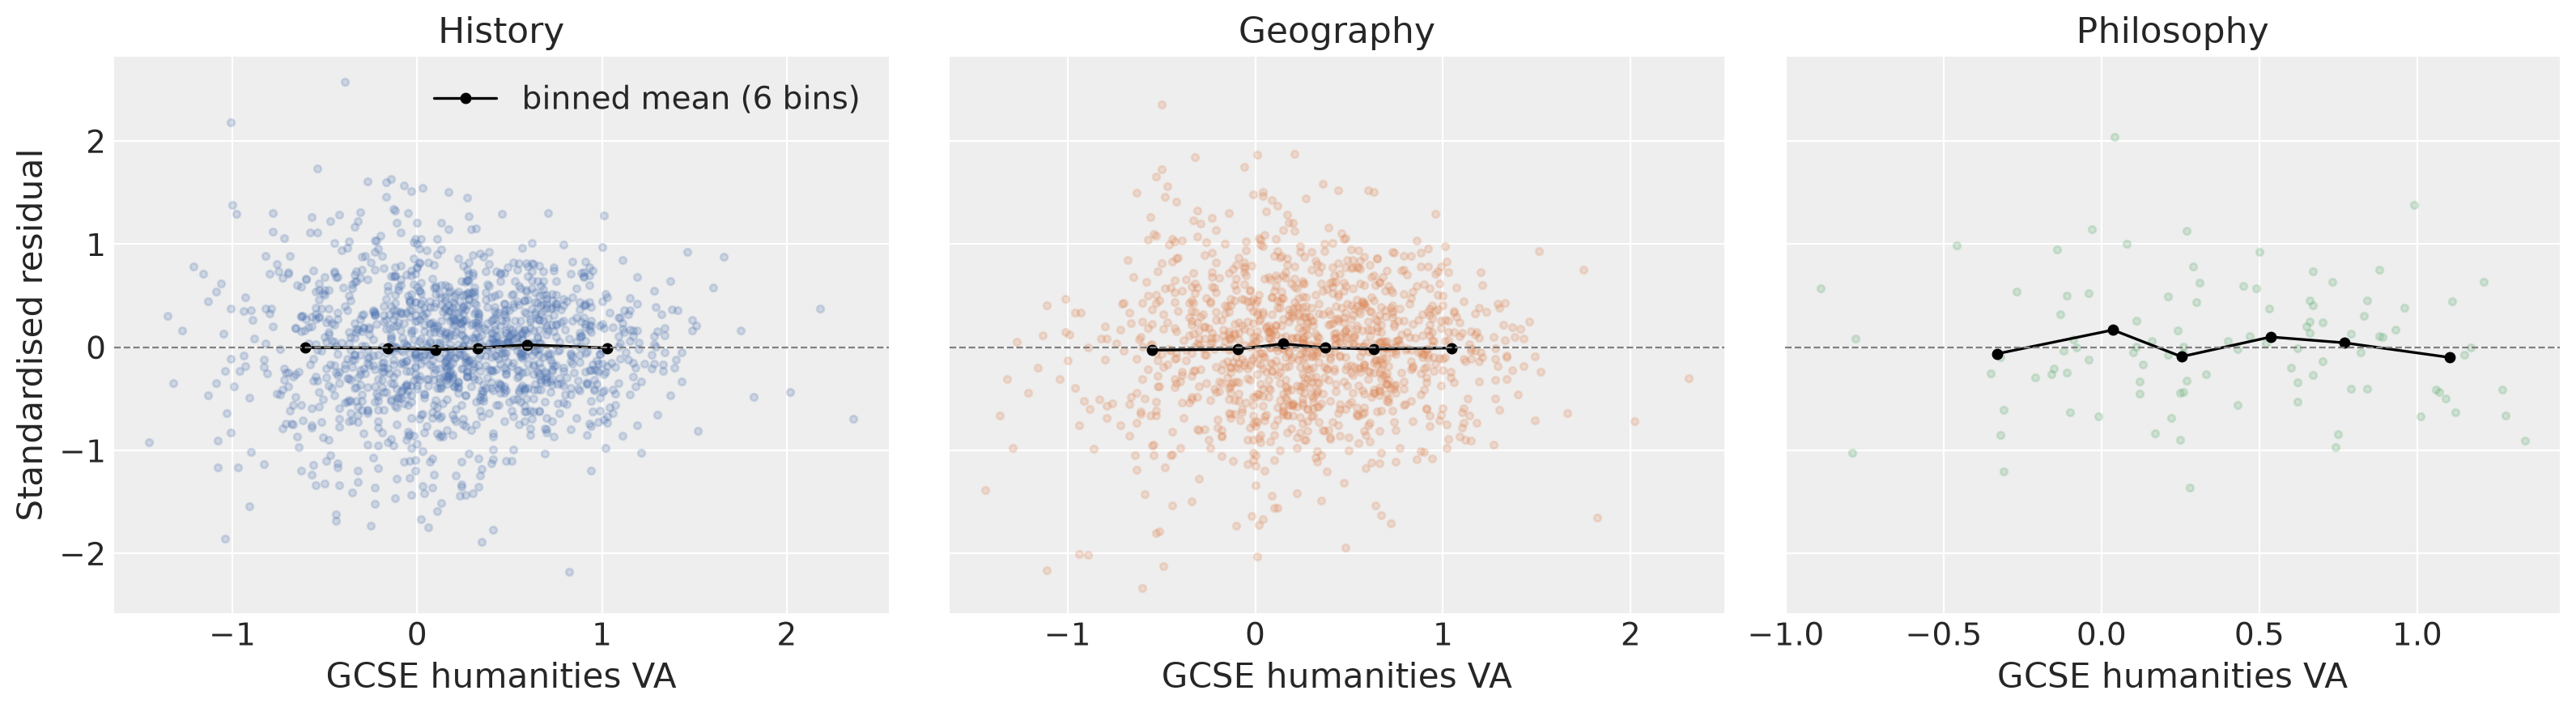

In [13]:
n_obs = len(long)
pred = idata_corr.posterior_predictive["alevel_obs"].to_numpy().reshape(-1, n_obs)
long["std_resid"] = (y_obs - pred.mean(axis=0)) / pred.std(axis=0)
long = long.merge(schools[["URN", "gcse_va"]], on="URN", how="left")
del pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, subject in zip(axes, subjects):
    g = long[long["subject"] == subject]
    binned = g.groupby(pd.qcut(g["gcse_va"], 6), observed=True).agg(gcse_va=("gcse_va", "mean"), r=("std_resid", "mean"))
    ax.scatter(g["gcse_va"], g["std_resid"], color=colors[subject], alpha=0.2, s=10)
    ax.plot(binned["gcse_va"], binned["r"], color="black", marker="o", markersize=4, linewidth=1.2, label="binned mean (6 bins)")
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_title(subject)
    ax.set_xlabel("GCSE humanities VA")
axes[0].set_ylabel("Standardised residual")
axes[0].legend()
plt.tight_layout()
plt.show()

### Do the strongest GCSE schools "top out"?

Mean A-level VA by GCSE humanities VA quintile, for each subject. (Philosophy has about 20 schools per quintile, so read its bars with care.)

subject,History,Geography,Philosophy
gcse_quintile,,,
1,-0.147,-0.148,-0.125
2,-0.056,-0.084,-0.031
3,-0.012,-0.034,0.096
4,0.045,0.028,0.014
5,0.114,0.076,0.008


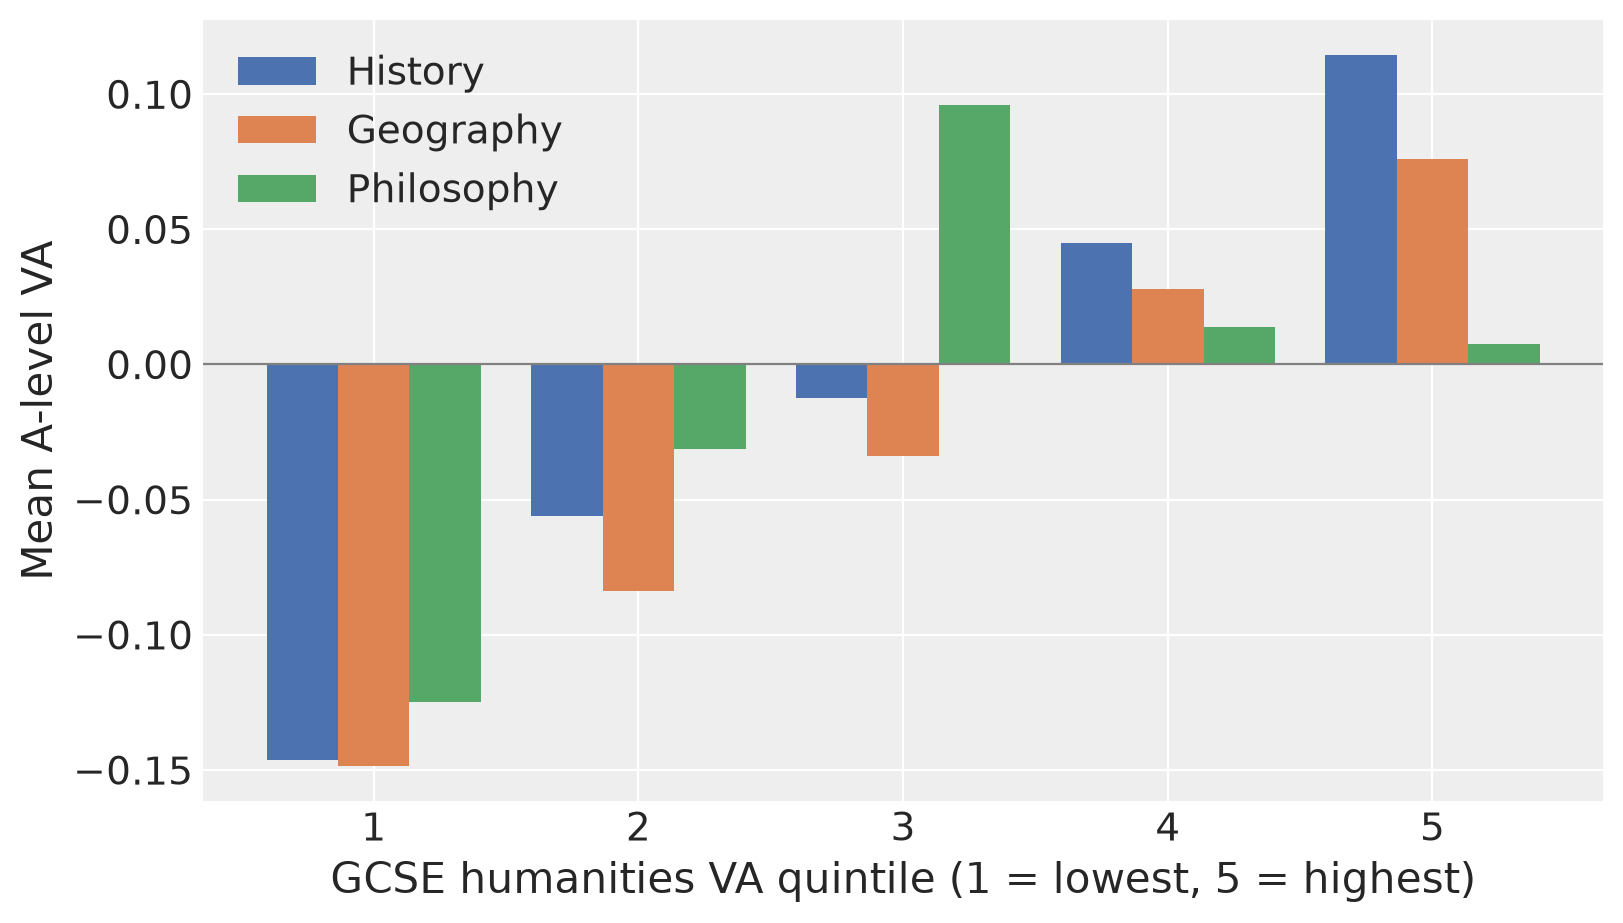

In [14]:
quint = []
for subject, g in long.groupby("subject"):
    t = g.groupby(pd.qcut(g["gcse_va"], 5, labels=range(1, 6)), observed=True).agg(
        mean_alevel_va=("alevel_va", "mean"), n=("URN", "count"))
    t["subject"] = subject
    quint.append(t)
quintile_table = pd.concat(quint).reset_index().rename(columns={"gcse_va": "gcse_quintile"})
display(quintile_table.pivot(index="gcse_quintile", columns="subject", values="mean_alevel_va")[subjects].round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.27
for k, subject in enumerate(subjects):
    t = quintile_table[quintile_table["subject"] == subject]
    ax.bar(t["gcse_quintile"].astype(int) + (k - 1) * width, t["mean_alevel_va"], width, color=colors[subject], label=subject)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel("GCSE humanities VA quintile (1 = lowest, 5 = highest)")
ax.set_ylabel("Mean A-level VA")
ax.legend()
plt.show()

### Is the shared-school-effect model worth attempting?

Before fitting the one-factor model, we check how much the data actually taught us about each correlation, compared with the LKJ(2) prior. A correlation that is no narrower than its prior would not support a model that builds on it.

In [15]:
r_grid = np.linspace(-0.9999, 0.9999, 20001)
prior_cdf = np.cumsum((1 - r_grid**2) ** 1.5)
prior_cdf /= prior_cdf[-1]
prior_lo, prior_hi = r_grid[np.searchsorted(prior_cdf, 0.055)], r_grid[np.searchsorted(prior_cdf, 0.945)]
print(f"LKJ(2) prior, 89% interval for each correlation: [{prior_lo:.2f}, {prior_hi:.2f}] (width {prior_hi - prior_lo:.2f})")

rows = []
for (i, j) in pairs:
    r = corr_s[..., i, j].ravel()
    lo, hi = np.percentile(r, [5.5, 94.5])
    rows.append({
        "pair": f"{subjects[i]}-{subjects[j]}",
        "schools_with_both": int(overlap.iloc[i, j]),
        "posterior_width": round(hi - lo, 2),
        "share_of_prior_width": round((hi - lo) / (prior_hi - prior_lo), 2),
    })
pd.DataFrame(rows)

LKJ(2) prior, 89% interval for each correlation: [-0.66, 0.66] (width 1.31)


,pair,schools_with_both,posterior_width,share_of_prior_width
0,History-Geography,1040,0.18,0.13
1,History-Philosophy,95,0.55,0.42
2,Geography-Philosophy,89,0.63,0.48


The History-Geography correlation is pinned down well (its interval is 13% of the prior's width, from 1,040 schools). The two Philosophy correlations are only moderately narrower than the prior (42% and 48%, from about 90 schools each). That is borderline for a model that builds a shared effect on them. Because 85 schools do have all three subjects, we fit the one-factor model anyway to see, but the next sections show it does **not** sample cleanly here, so the correlated-residuals model is the one to rely on.

## Interpretation

- **GCSE humanities VA predicts A-level History and Geography modestly, and Philosophy not detectably.** The slopes are 0.19 for History (89% interval 0.16-0.22) and 0.17 for Geography (0.13-0.20), a little below the sciences (0.21-0.23) and well below Spanish. Philosophy is 0.11 (-0.05 to 0.27): it is consistent with the other two, but the interval also includes zero, and it rests on only 100 schools. Bayesian $R^2$ from GCSE humanities VA is 0.12 for History, 0.10 for Geography and 0.04 (0.00-0.14) for Philosophy. So, as elsewhere, GCSE VA is a real but small part of the story.
- **History and Geography effects are only moderately related within a school.** After removing the GCSE effect, the correlation between a school's true History and Geography effects is 0.39 (0.30-0.48). That is well determined, and clearly weaker than Chemistry-Biology (0.84) or Physics-Chemistry (0.76) in the sciences, and closer to Spanish-French (0.50). A school that does unusually well in A-level History, given its GCSE VA, tends to do somewhat better in Geography, but there is a lot of department-specific variation.
- **The Philosophy correlations are not well learned.** History-Philosophy is 0.29 (0.005-0.56) and Geography-Philosophy is 0.09 (-0.22 to 0.41). Both intervals are about half the width of the LKJ(2) prior, so the data have told us something but not much. The point estimates should not be over-read.
- **No sign of topping out.** Mean A-level VA rises across GCSE humanities quintiles for History (-0.15 to +0.11) and Geography (-0.15 to +0.08), and the binned residuals stay flat around zero. Philosophy rises and then flattens (-0.13, -0.03, +0.10, +0.01, +0.01), but with about 20 schools per quintile and a standard error of about 0.1 per bar that is not distinguishable from noise.
- **Data.** 1,471 schools have at least one of the three subjects: 417 have one, 969 have two (mostly History and Geography) and 85 have all three. A-level cohorts are small (median 14 entries for History, 13 for Geography, 10 for Philosophy), so each A-level VA has a standard error of 0.25-0.31.
- **Caveats.** Single year of data; PSIS-LOO is not usable for these latent-variable models. As we understand DfE's definition, the GCSE humanities element is built from GCSE history and geography, which is the natural precursor for A-level History and Geography but less so for Philosophy. Sampling was clean (0 divergences, r_hat at most 1.009).

## A shared school effect (one-factor model)

The correlated-residuals model estimates the correlations directly. The more complex alternative gives each school a single latent **humanities effect** $u_i$ that lifts or lowers all three subjects, and lets the remaining subject-specific noise be independent:

$$
\begin{aligned}
u_i &\sim \text{Normal}(0, 1) \\
y_{is} &= \alpha_s + \beta_s x_i + \lambda_s u_i + \epsilon_{is}, \qquad \epsilon_{is} \sim \text{Normal}(0, \tau_s), \qquad y_{is}^{obs} \sim \text{Normal}(y_{is}, \sigma^y_{is})
\end{aligned}
$$

$\lambda_s > 0$ is how strongly subject $s$ loads on the shared effect (fixing the scale of $u_i$ at 1 and the sign by constraining $\lambda_s$ positive). This is a one-factor model. It implies a correlation between subjects $s$ and $t$ of $\lambda_s\lambda_t / \sqrt{(\lambda_s^2+\tau_s^2)(\lambda_t^2+\tau_t^2)}$, so it is a more restrictive structure than a free correlation matrix, but it gives each school an explicit shared effect $u_i$ that we can look at.

As in the science notebook, we **marginalise out** the subject-specific noise $\epsilon_{is}$ analytically: given $u_i$, $y_{is}^{obs} \sim \text{Normal}(\alpha_s + \beta_s x_i + \lambda_s u_i,\ \sqrt{\tau_s^2 + (\sigma^y_{is})^2})$. That removes a latent parameter per observation. One difference from the sciences: here most schools have exactly two subjects (History and Geography), and only a small minority have all three, so Philosophy's loading is learned from a small set of schools.

In [16]:
with pm.Model(coords={"subject": subjects}) as factor_model:
    mu_x = pm.Normal("mu_x", 0, 1)
    tau_x = pm.HalfNormal("tau_x", 1)
    x_raw = pm.Normal("x_raw", 0, 1, shape=n_schools)
    x_true = mu_x + tau_x * x_raw

    alpha = pm.Normal("alpha", 0, 1, dims="subject")
    beta = pm.Normal("beta", 0, 1, dims="subject")
    lam = pm.HalfNormal("lam", 0.5, dims="subject")
    tau_y = pm.HalfNormal("tau_y", 1, dims="subject")
    u = pm.Normal("u", 0, 1, shape=n_schools)

    mean = alpha[subj_idx] + beta[subj_idx] * x_true[s_idx] + lam[subj_idx] * u[s_idx]
    total_sd = pt.sqrt(tau_y[subj_idx] ** 2 + y_se**2)

    pm.Normal("gcse_obs", mu=x_true, sigma=gcse_se, observed=gcse_obs)
    pm.Normal("alevel_obs", mu=mean, sigma=total_sd, observed=y_obs)

with factor_model:
    idata_factor = pm.sample(draws=1000, tune=2000, chains=4, target_accept=0.99,
                             random_seed=RANDOM_SEED, progressbar=False)

NUTS[nutpie]: [mu_x, tau_x, x_raw, alpha, beta, lam, tau_y, u]


In [17]:
print(f"divergences = {int(idata_factor.sample_stats['diverging'].sum())}")
az.summary(idata_factor, var_names=["alpha", "beta", "lam", "tau_y", "mu_x", "tau_x"], round_to=3)

divergences = 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha[History],-0.048,0.011,-0.066,-0.030,2807.139,2967.159,1.003,0.000,0.000
alpha[Geography],-0.071,0.013,-0.091,-0.050,3018.626,2953.215,1.001,0.000,0.000
alpha[Philosophy],-0.069,0.058,-0.158,0.021,2655.205,2827.617,1.001,0.001,0.001
beta[History],0.185,0.019,0.156,0.216,2671.687,2781.380,1.001,0.000,0.000
beta[Geography],0.168,0.022,0.134,0.204,2464.077,2530.606,1.001,0.000,0.000
beta[Philosophy],0.127,0.096,-0.024,0.279,2988.108,2810.217,1.001,0.002,0.001
lam[History],0.203,0.045,0.125,0.265,47.294,75.101,1.087,0.006,0.003
lam[Geography],0.140,0.040,0.091,0.217,64.201,89.412,1.057,0.005,0.004
lam[Philosophy],0.126,0.067,0.026,0.241,833.612,938.362,1.002,0.002,0.001
tau_y[History],0.152,0.062,0.035,0.235,37.857,43.387,1.103,0.010,0.007


### Does it agree with the correlated-residuals model?

The one-factor model implies a correlation between each pair of subjects. We compare it with the correlations the free correlation matrix estimated, and with the slopes.

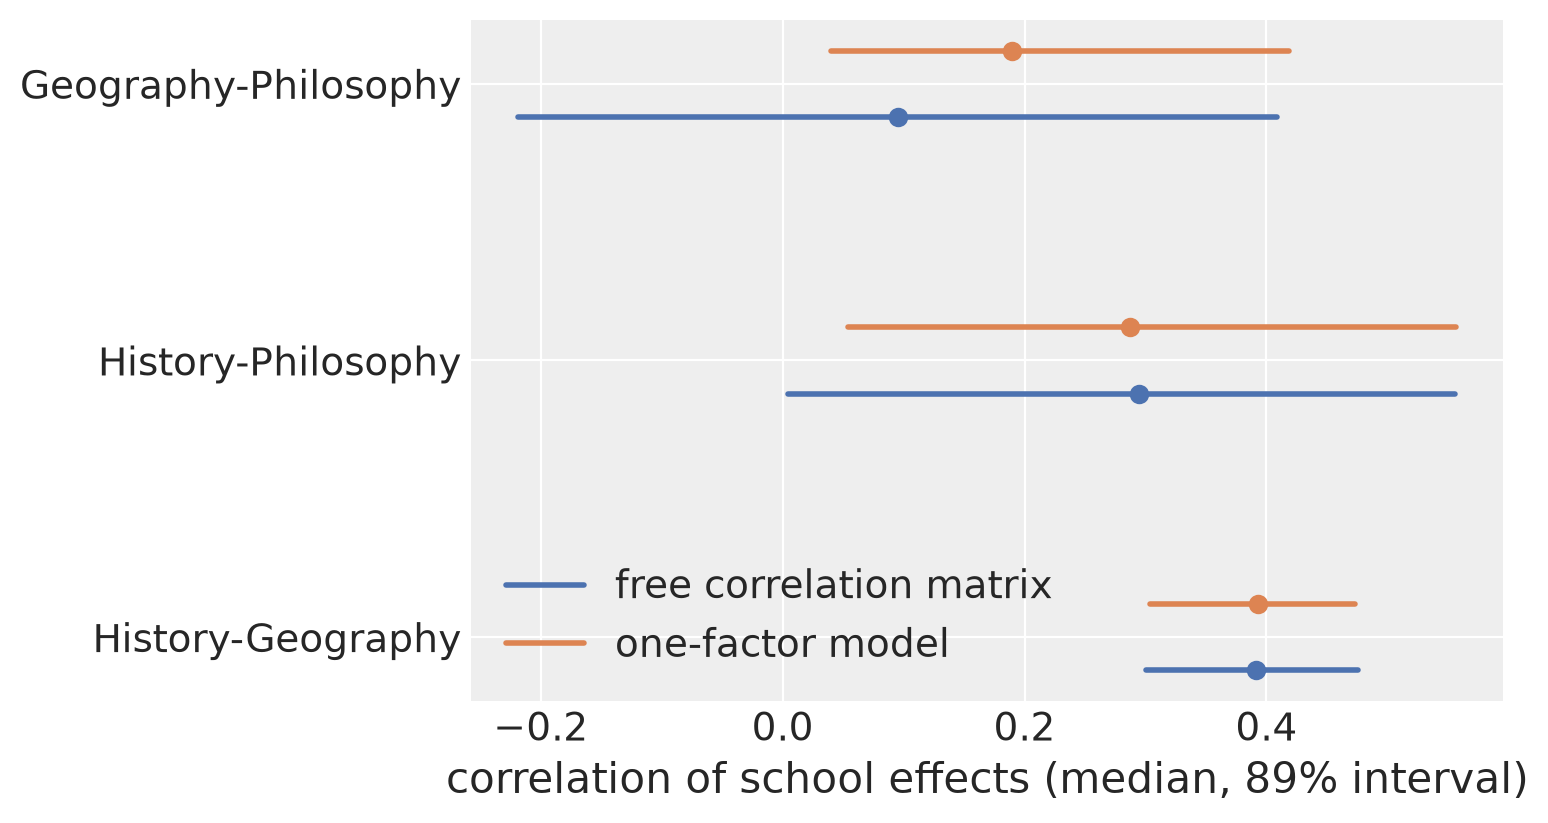

History-Geography    free: mean=0.390, 89% interval [0.300, 0.475]
                     factor: mean=0.391, 89% interval [0.304, 0.474]
History-Philosophy   free: mean=0.288, 89% interval [0.005, 0.556]
                     factor: mean=0.293, 89% interval [0.054, 0.557]
Geography-Philosophy free: mean=0.094, 89% interval [-0.219, 0.408]
                     factor: mean=0.205, 89% interval [0.040, 0.419]

beta History    corr model: mean=0.186, 89% interval [0.155, 0.218]   factor model: mean=0.185, 89% interval [0.156, 0.216]
beta Geography  corr model: mean=0.168, 89% interval [0.132, 0.203]   factor model: mean=0.168, 89% interval [0.134, 0.204]
beta Philosophy corr model: mean=0.111, 89% interval [-0.050, 0.273]   factor model: mean=0.127, 89% interval [-0.024, 0.279]


In [18]:
pf = idata_factor.posterior
lam_s = pf["lam"].to_numpy()
tau_s = pf["tau_y"].to_numpy()

pair_names, implied, free = [], {}, {}
for i, j in pairs:
    name = f"{subjects[i]}-{subjects[j]}"
    pair_names.append(name)
    implied[name] = (lam_s[..., i] * lam_s[..., j] / np.sqrt((lam_s[..., i]**2 + tau_s[..., i]**2) * (lam_s[..., j]**2 + tau_s[..., j]**2))).ravel()
    free[name] = corr_s[..., i, j].ravel()

fig, ax = plt.subplots(figsize=(7.5, 4))
for k, name in enumerate(pair_names):
    for off, d, c, lab in [(-0.12, free[name], "#4C72B0", "free correlation matrix"), (0.12, implied[name], "#DD8452", "one-factor model")]:
        lo, m, hi = np.percentile(d, [5.5, 50, 94.5])
        ax.plot([lo, hi], [k + off, k + off], color=c, linewidth=2, label=lab if k == 0 else None)
        ax.plot(m, k + off, "o", color=c)
ax.set_yticks(range(3), pair_names)
ax.set_xlabel("correlation of school effects (median, 89% interval)")
ax.legend(loc="lower left")
plt.show()

for name in pair_names:
    print(f"{name:20s} free: {summarise(free[name])}\n{'':20s} factor: {summarise(implied[name])}")
print()
for k, s in enumerate(subjects):
    print(f"beta {s:10s} corr model: {summarise(post['beta'].sel(subject=s).to_numpy().ravel())}   factor model: {summarise(pf['beta'].sel(subject=s).to_numpy().ravel())}")

### How much of each subject is the shared effect?

The share of each subject's residual variance (after GCSE) that is the shared school effect, $\lambda_s^2/(\lambda_s^2+\tau_s^2)$, and the Bayesian $R^2$ from GCSE alone and from GCSE plus the shared effect.

In [19]:
xf = pf["mu_x"].to_numpy()[..., None] + pf["tau_x"].to_numpy()[..., None] * pf["x_raw"].to_numpy()
uf = pf["u"].to_numpy()
for k, s in enumerate(subjects):
    sch = s_idx[subj_idx == k]
    l, t = lam_s[..., k], tau_s[..., k]
    fit_gcse = pf["alpha"].sel(subject=s).to_numpy()[..., None] + pf["beta"].sel(subject=s).to_numpy()[..., None] * xf[..., sch]
    var_g = fit_gcse.var(axis=-1)
    var_u = (l[..., None] * uf[..., sch]).var(axis=-1)
    print(f"{s}:")
    print(f"  shared share of residual variance: {summarise((l**2 / (l**2 + t**2)).ravel())}")
    print(f"  R² from GCSE only:                 {summarise((var_g / (var_g + var_u + t**2)).ravel())}")
    print(f"  R² from GCSE + shared effect:      {summarise(((var_g + var_u) / (var_g + var_u + t**2)).ravel())}")

History:
  shared share of residual variance: mean=0.614, 89% interval [0.223, 0.983]
  R² from GCSE only:                 mean=0.119, 89% interval [0.085, 0.155]
  R² from GCSE + shared effect:      mean=0.659, 89% interval [0.311, 0.985]


Geography:
  shared share of residual variance: mean=0.313, 89% interval [0.126, 0.686]
  R² from GCSE only:                 mean=0.101, 89% interval [0.065, 0.143]
  R² from GCSE + shared effect:      mean=0.379, 89% interval [0.206, 0.711]
Philosophy:
  shared share of residual variance: mean=0.185, 89% interval [0.006, 0.512]
  R² from GCSE only:                 mean=0.048, 89% interval [0.000, 0.145]
  R² from GCSE + shared effect:      mean=0.218, 89% interval [0.023, 0.525]


### Pooling in action

How well is each school's shared effect $u_i$ pinned down, as a function of how many of the three subjects the school has? Schools with more subjects give more information about $u_i$.

,mean,count
n_subjects,,
1,0.877,417
2,0.770,969
3,0.728,85


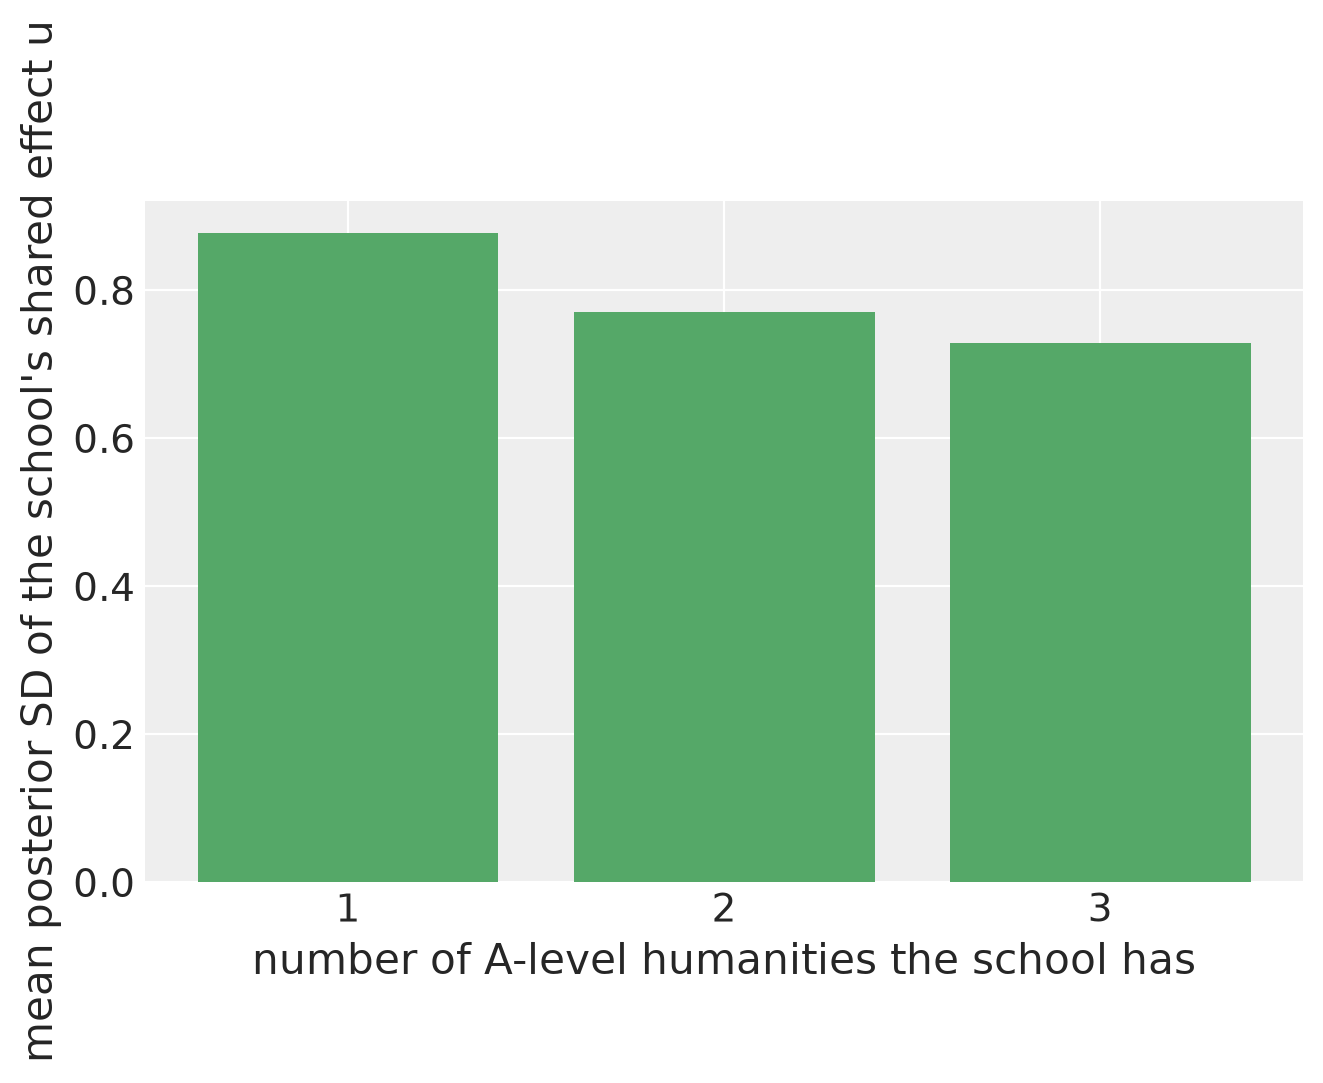

In [20]:
n_sub = long.groupby("school_idx")["subject"].nunique().reindex(range(n_schools)).to_numpy()
u_sd = uf.reshape(-1, n_schools).std(axis=0)
summary = pd.DataFrame({"n_subjects": n_sub, "posterior_sd_u": u_sd}).groupby("n_subjects")["posterior_sd_u"].agg(["mean", "count"]).round(3)
display(summary)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(summary.index.astype(int), summary["mean"], color="#55A868")
ax.set_xticks([1, 2, 3])
ax.set_xlabel("number of A-level humanities the school has")
ax.set_ylabel("mean posterior SD of the school's shared effect u")
plt.show()

## Interpretation of the shared-effect model

- **It did not sample cleanly, so we do not rely on it.** There were no divergences, but r_hat is 1.10 for History's subject-specific SD and 1.09 for its loading (1.06 for Geography's), and their effective sample sizes are only about 40-90. The correlated-residuals model, by contrast, has r_hat of at most 1.009.
- **What is robust.** The slopes match the correlated-residuals model (History 0.185 vs 0.186, Geography 0.168 vs 0.168, Philosophy 0.127 vs 0.111), and the implied History-Geography (0.39) and History-Philosophy (0.29) correlations match the free ones. The implied Geography-Philosophy correlation (0.21, interval 0.04-0.42) is above the free estimate (0.09, interval -0.22 to 0.41) because the one-factor structure forces the correlations to be positive and to multiply, so its narrower interval comes from the constraint, not the data.
- **What is not identified.** How much of each subject's residual variance is shared is very uncertain (History 0.61, interval 0.22-0.98; Geography 0.31, 0.13-0.69; Philosophy 0.19, 0.01-0.51). Most schools have only two subjects, and two scores cannot separate a shared effect from a subject-specific one. Only the 85 three-subject schools help, so History could be almost entirely shared or half shared and the data cannot say which. The "R² from GCSE + shared effect" figures (0.66, 0.38, 0.22) inherit that uncertainty and should not be quoted.
- **Pooling barely helps.** The posterior SD of a school's shared effect is 0.88 for schools with one subject, 0.77 with two and 0.73 with three, against a prior SD of 1. Compare the sciences (0.85, 0.66, 0.50). The shared effect is hardly pinned down for any school.
- **Conclusion.** A one-factor model on three subjects, two of which nearly always come together, is not identified well enough to use. A factor structure would need many more subjects per school, which is the case for an all-subjects model.

## Regional effects

Does the relationship between GCSE humanities VA and A-level VA differ by region? We extend the correlated-residuals model so that each subject's intercept and slope vary by region (the 9 English regions, `RGN24NM`), with partial pooling:

$$
\alpha_{sr} = \alpha_s + \sigma_\alpha\, a_{sr}, \qquad \beta_{sr} = \beta_s + \sigma_\beta\, b_{sr}, \qquad a_{sr}, b_{sr} \sim \text{Normal}(0, 1)
$$

The spreads $\sigma_\alpha$ and $\sigma_\beta$ are shared across subjects (with only 9 regions there is little information for separate ones), so the model estimates one typical size of regional difference in baseline A-level VA and one in the slope, while letting each subject's regional pattern differ. Both get a tight `HalfNormal(0.5)` prior. Everything else, including the LKJ correlation of school residuals across subjects, is unchanged.

First, the raw picture: mean GCSE and A-level VA by region and the number of schools.

In [21]:
region_of_school = schools["URN"].map(raw.set_index("URN")["RGN24NM"])
region_idx, region_labels = pd.factorize(region_of_school)
n_regions = len(region_labels)
r_idx = region_idx[s_idx]

raw_by_region = pd.DataFrame({"schools": region_of_school.value_counts(), "mean GCSE VA": schools.groupby(region_of_school)["gcse_va"].mean()})
for subject in subjects:
    g = long[long["subject"] == subject]
    raw_by_region[f"mean A-level {subject} VA"] = g.groupby(g["URN"].map(raw.set_index("URN")["RGN24NM"]))["alevel_va"].mean()
raw_by_region.round(3).sort_values("schools", ascending=False)

,schools,mean GCSE VA,mean A-level History VA,mean A-level Geography VA,mean A-level Philosophy VA
URN,,,,,
London,299,0.377,0.093,0.081,0.112
South East,243,0.237,-0.029,-0.055,0.085
East of England,188,0.151,0.047,-0.010,-0.219
West Midlands,173,-0.012,-0.116,-0.077,-0.275
South West,151,0.205,-0.093,-0.107,-0.432
East Midlands,137,0.088,-0.068,-0.035,0.208
North West,123,0.095,0.048,-0.089,-0.001
Yorkshire and The Humber,99,0.177,-0.033,-0.025,0.182
North East,58,-0.101,-0.127,-0.102,-0.190


In [22]:
with pm.Model(coords={"subject": subjects, "region": region_labels}) as region_model:
    mu_x = pm.Normal("mu_x", 0, 1)
    tau_x = pm.HalfNormal("tau_x", 1)
    x_raw = pm.Normal("x_raw", 0, 1, shape=n_schools)
    x_true = mu_x + tau_x * x_raw

    alpha = pm.Normal("alpha", 0, 1, dims="subject")
    beta = pm.Normal("beta", 0, 1, dims="subject")
    sigma_alpha = pm.HalfNormal("sigma_alpha", 0.5)
    sigma_beta = pm.HalfNormal("sigma_beta", 0.5)
    a_raw = pm.Normal("a_raw", 0, 1, dims=("subject", "region"))
    b_raw = pm.Normal("b_raw", 0, 1, dims=("subject", "region"))
    alpha_sr = pm.Deterministic("alpha_sr", alpha[:, None] + sigma_alpha * a_raw, dims=("subject", "region"))
    beta_sr = pm.Deterministic("beta_sr", beta[:, None] + sigma_beta * b_raw, dims=("subject", "region"))

    chol, corr, stds = pm.LKJCholeskyCov(
        "chol_cov", n=n_subjects, eta=2.0, sd_dist=pm.HalfNormal.dist(1.0, shape=n_subjects), compute_corr=True
    )
    z = pm.Normal("z", 0, 1, shape=(n_schools, n_subjects))
    eps = pt.dot(z, chol.T)[s_idx, subj_idx]

    y_true = alpha_sr[subj_idx, r_idx] + beta_sr[subj_idx, r_idx] * x_true[s_idx] + eps

    pm.Normal("gcse_obs", mu=x_true, sigma=gcse_se, observed=gcse_obs)
    pm.Normal("alevel_obs", mu=y_true, sigma=y_se, observed=y_obs)

with region_model:
    idata_region = pm.sample(draws=1000, tune=2000, chains=4, target_accept=0.99,
                             random_seed=RANDOM_SEED, progressbar=False)

NUTS[nutpie]: [mu_x, tau_x, x_raw, alpha, beta, sigma_alpha, sigma_beta, a_raw, b_raw, chol_cov, z]


In [23]:
print(f"divergences = {int(idata_region.sample_stats['diverging'].sum())}")
az.summary(idata_region, var_names=["sigma_alpha", "sigma_beta", "alpha", "beta", "chol_cov_stds", "mu_x", "tau_x"], round_to=3)

divergences = 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_alpha,0.069,0.019,0.043,0.102,805.033,1280.267,1.000,0.001,0.000
sigma_beta,0.067,0.027,0.027,0.113,688.206,799.457,1.002,0.001,0.001
alpha[History],-0.055,0.026,-0.097,-0.015,798.824,1215.040,1.001,0.001,0.001
alpha[Geography],-0.071,0.028,-0.116,-0.027,1017.160,1350.928,1.003,0.001,0.001
alpha[Philosophy],-0.077,0.063,-0.176,0.023,2622.311,2849.328,1.001,0.001,0.001
beta[History],0.185,0.033,0.134,0.238,1411.376,1471.097,1.001,0.001,0.001
beta[Geography],0.167,0.034,0.114,0.222,1888.645,2186.085,1.002,0.001,0.001
beta[Philosophy],0.074,0.102,-0.089,0.233,2518.917,2882.151,1.002,0.002,0.001
chol_cov_stds[0],0.258,0.009,0.243,0.274,2015.606,2502.620,1.000,0.000,0.000
chol_cov_stds[1],0.254,0.011,0.237,0.272,2050.050,2433.193,1.001,0.000,0.000


### How big are the regional differences?

The posteriors of the two spreads: `sigma_alpha` (typical regional shift in baseline A-level VA) and `sigma_beta` (typical regional difference in the slope). A spread near zero means regions look alike.

sigma_alpha: mean=0.069, 89% interval [0.043, 0.102]
sigma_beta: mean=0.067, 89% interval [0.027, 0.113]


/tmp/ipykernel_115664/2655007468.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


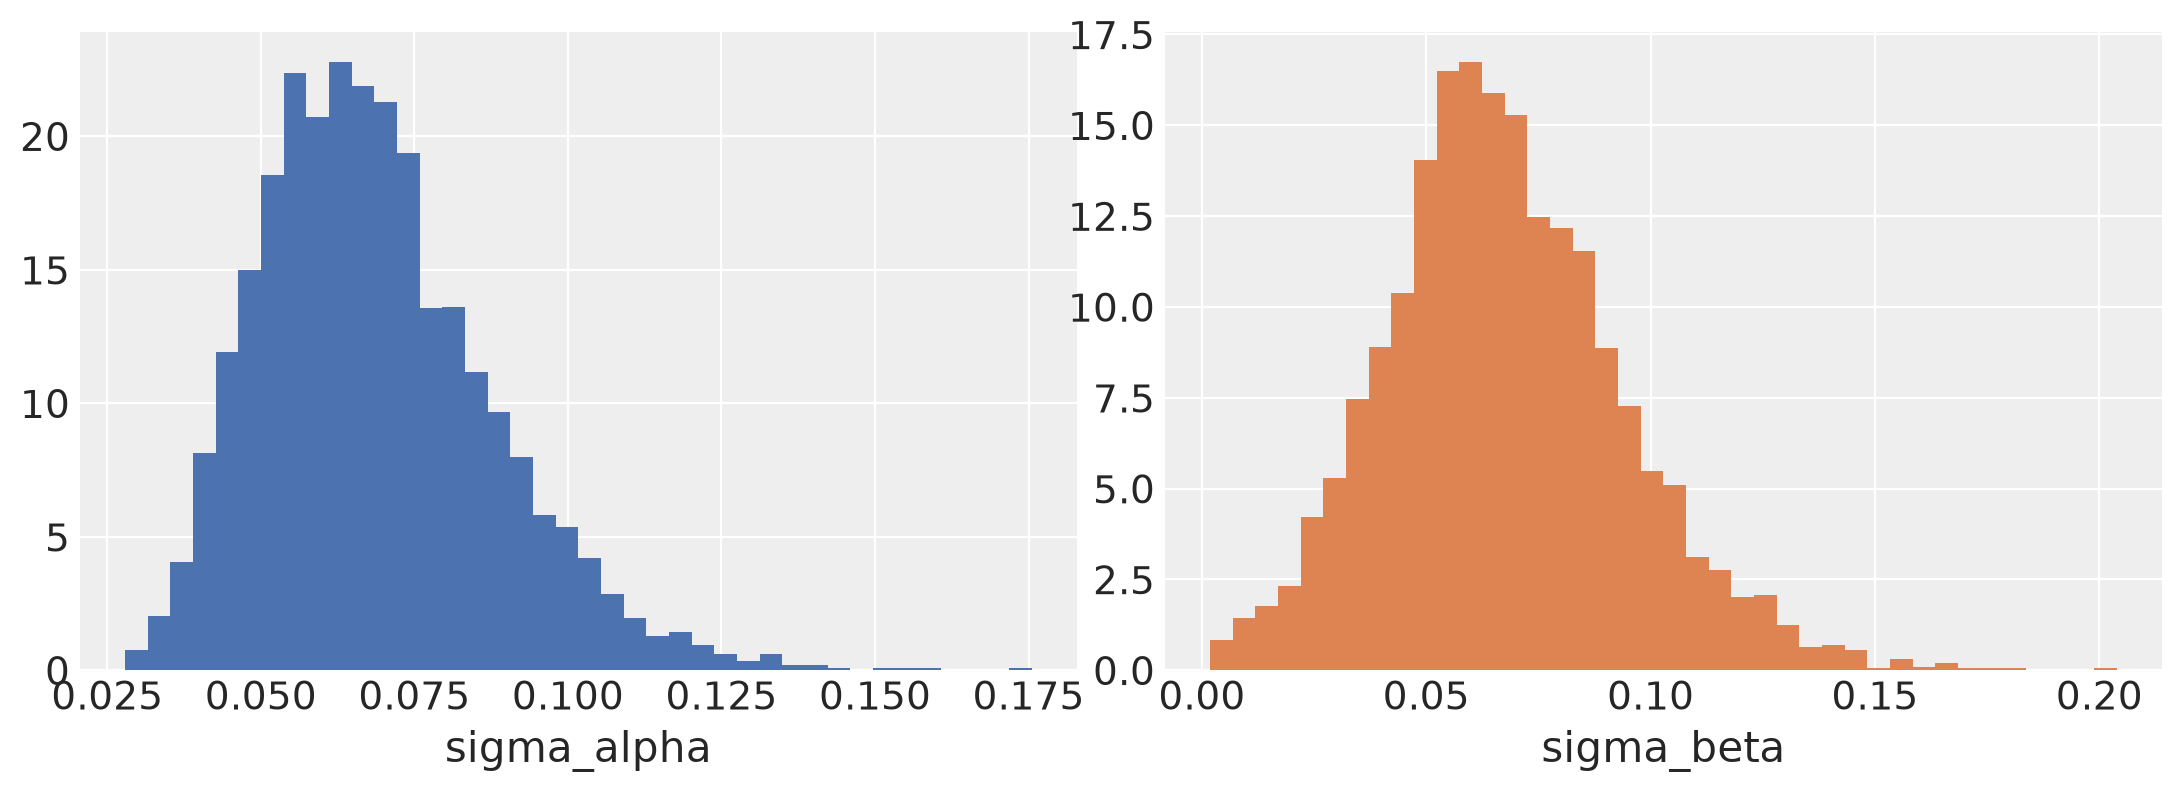

In [24]:
pr = idata_region.posterior
for name in ["sigma_alpha", "sigma_beta"]:
    print(f"{name}: {summarise(pr[name].to_numpy().ravel())}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name, c in zip(axes, ["sigma_alpha", "sigma_beta"], ["#4C72B0", "#DD8452"]):
    ax.hist(pr[name].to_numpy().ravel(), bins=40, density=True, color=c)
    ax.set_xlabel(name)
plt.tight_layout()
plt.show()

### Region by region

For each subject, each region's intercept and slope relative to that subject's average across regions (median and 89% interval). Regions are ordered by number of schools, largest at the top. Intervals that straddle zero mean the region is not distinguishable from the subject's average.

/tmp/ipykernel_115664/2102355965.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


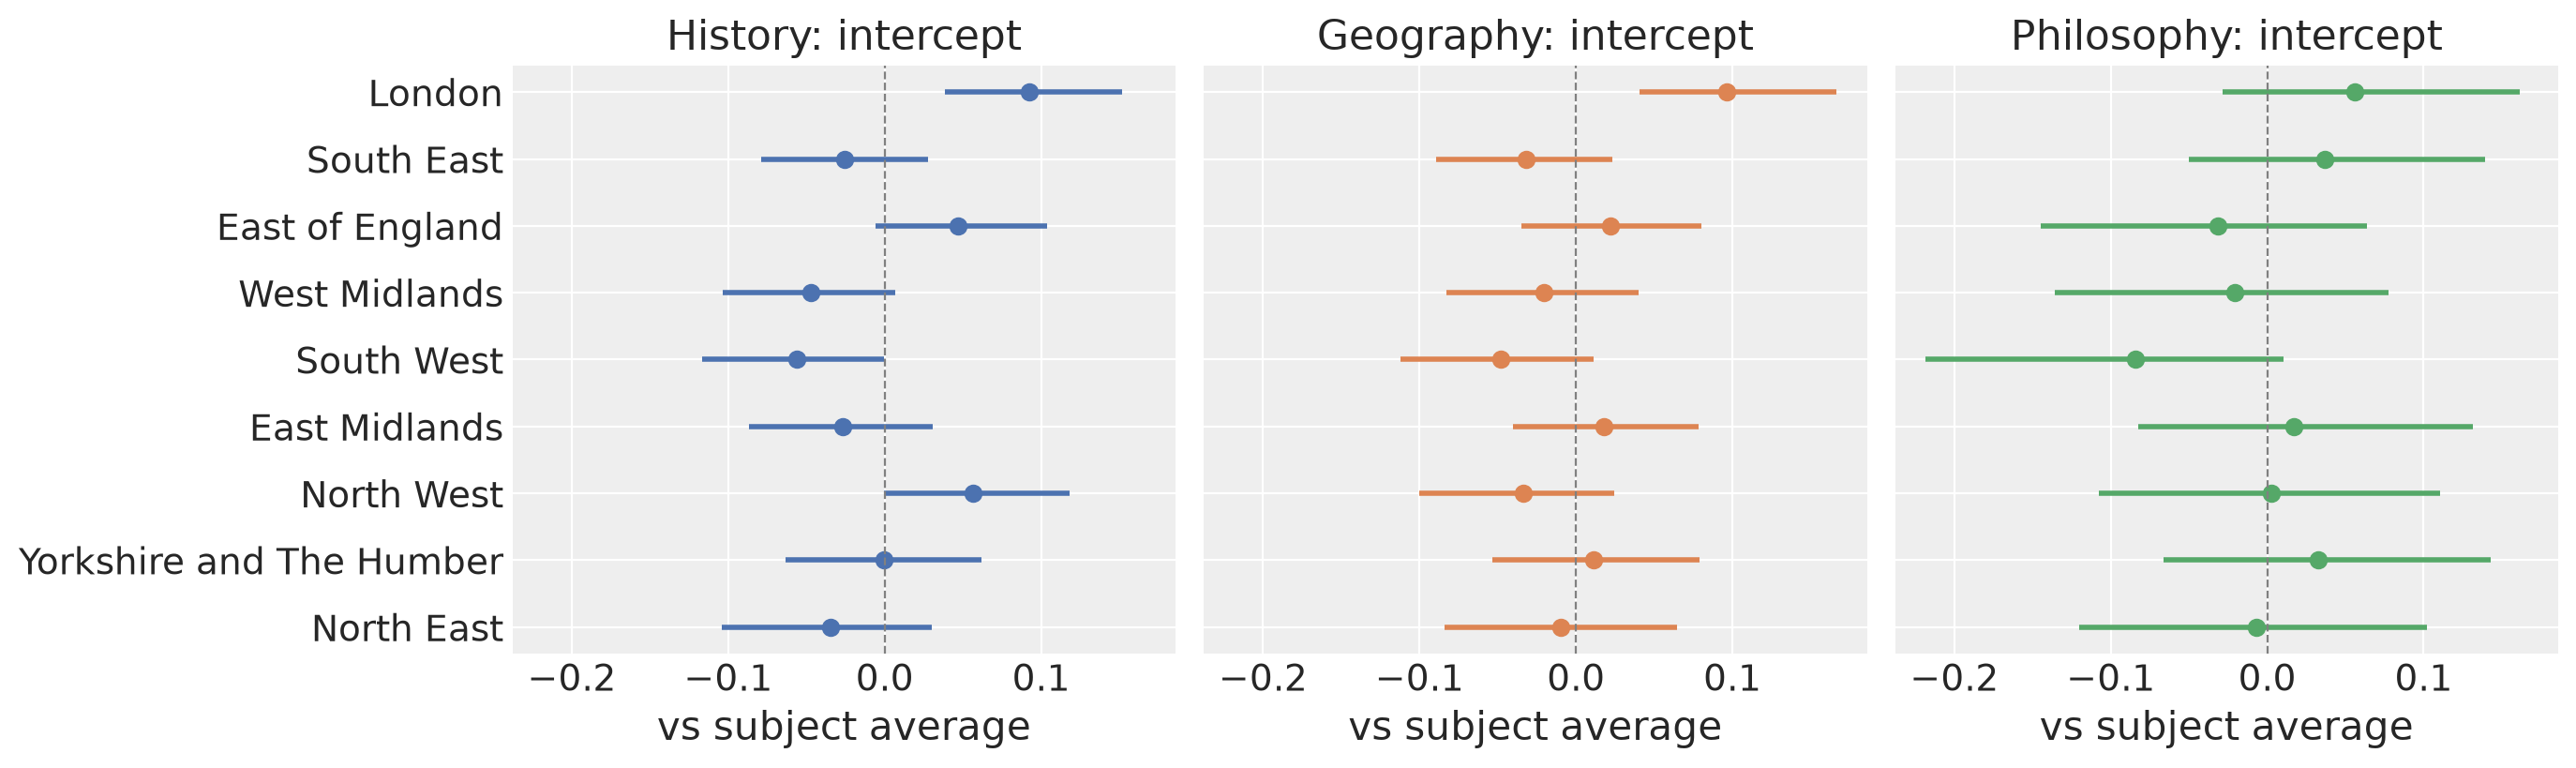

/tmp/ipykernel_115664/2102355965.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


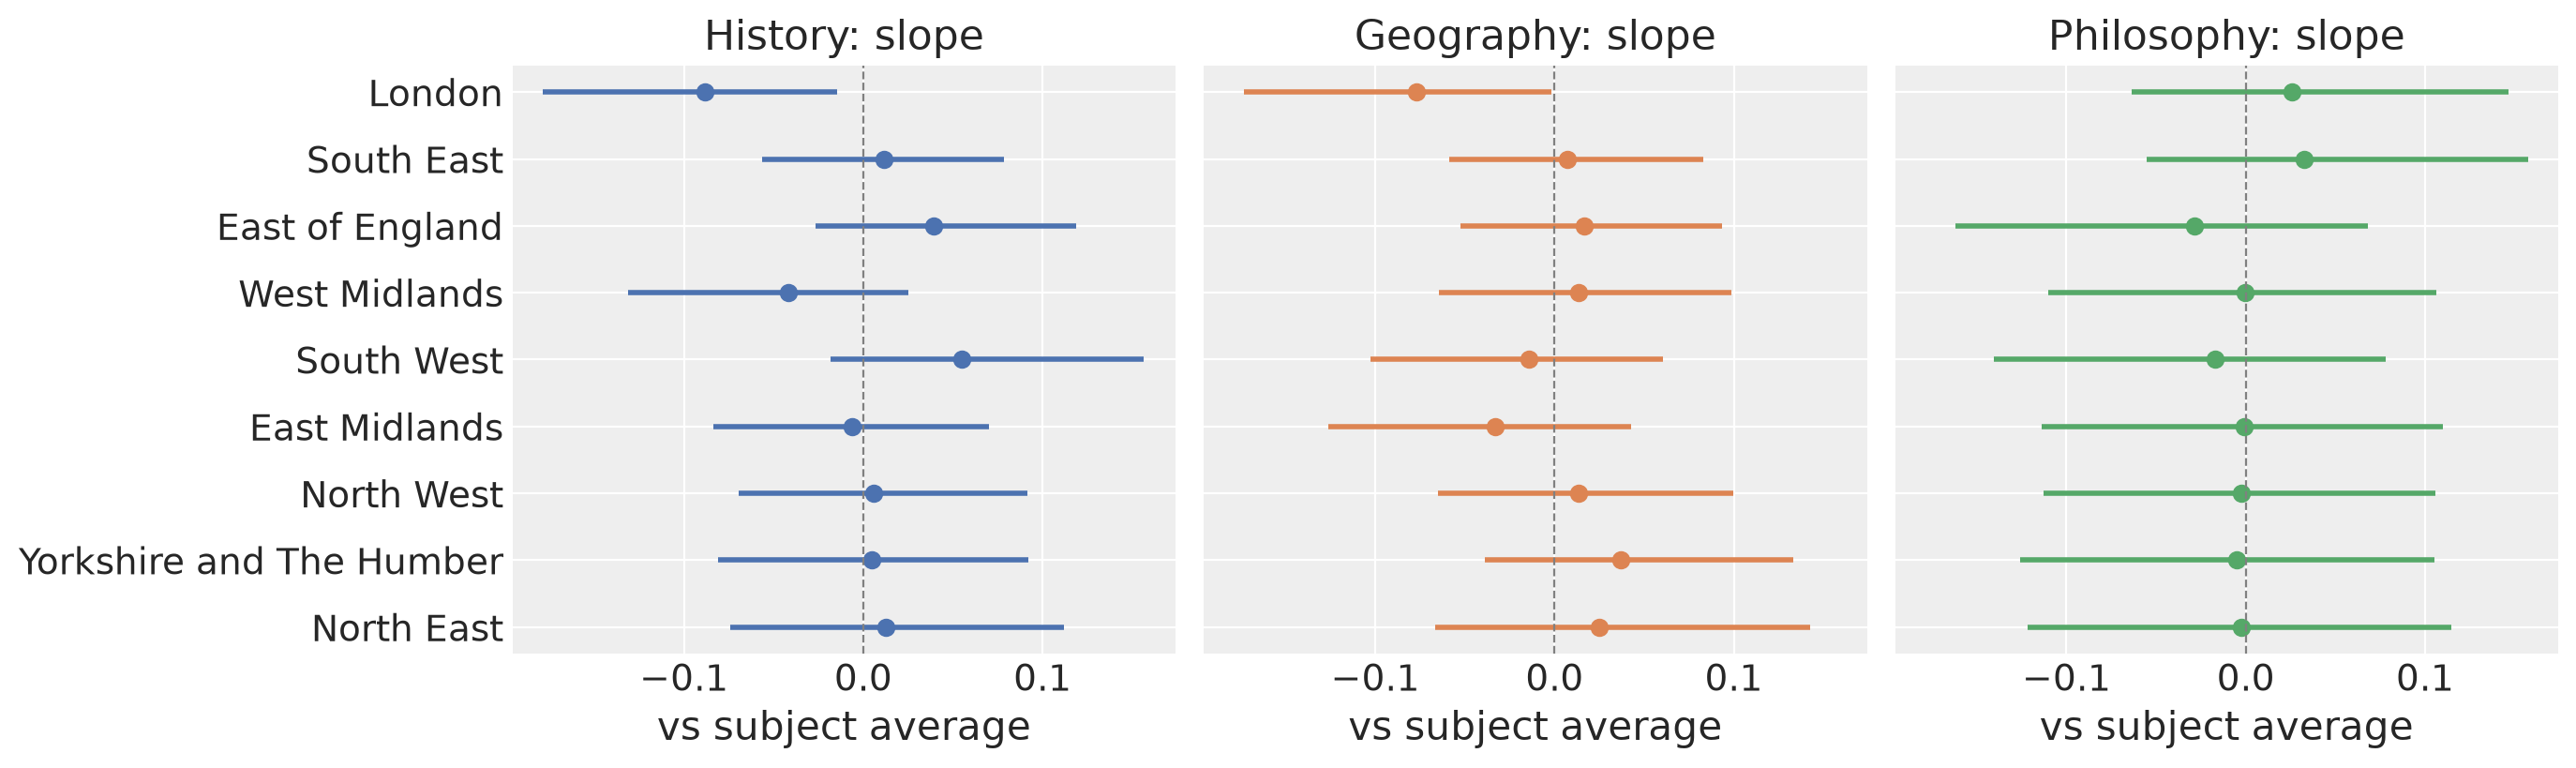

In [25]:
region_order = list(raw_by_region.sort_values("schools", ascending=False).index)
ord_idx = [list(region_labels).index(r) for r in region_order]

def region_deviation_plot(var, base, title):
    dev = (pr[var] - pr[base]).transpose("chain", "draw", "subject", "region").to_numpy()
    fig, axes = plt.subplots(1, n_subjects, figsize=(4.6 * n_subjects, 4.2), sharey=True, sharex=True)
    for k, (ax, subject) in enumerate(zip(np.atleast_1d(axes), subjects)):
        d = dev[:, :, k, :].reshape(-1, n_regions)[:, ord_idx]
        lo, med, hi = np.percentile(d, [5.5, 50, 94.5], axis=0)
        y = np.arange(n_regions)[::-1]
        ax.hlines(y, lo, hi, color=colors[subject], linewidth=2)
        ax.plot(med, y, "o", color=colors[subject])
        ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
        ax.set_title(f"{subject}: {title}")
        ax.set_yticks(y, region_order)
        ax.set_xlabel("vs subject average")
    plt.tight_layout()
    plt.show()

region_deviation_plot("alpha_sr", "alpha", "intercept")
region_deviation_plot("beta_sr", "beta", "slope")

### Does region change the picture?

The subject-level slopes (now the average across regions) and Bayesian $R^2$ with and without regional terms, and the cross-subject correlations.

In [26]:
xr = pr["mu_x"].to_numpy()[..., None] + pr["tau_x"].to_numpy()[..., None] * pr["x_raw"].to_numpy()
a_sr = pr["alpha_sr"].transpose("chain", "draw", "subject", "region").to_numpy()
b_sr = pr["beta_sr"].transpose("chain", "draw", "subject", "region").to_numpy()
stds_r = pr["chol_cov_stds"].to_numpy()
for k, s in enumerate(subjects):
    m = subj_idx == k
    sch, reg = s_idx[m], r_idx[m]
    fit = a_sr[:, :, k, :][..., reg] + b_sr[:, :, k, :][..., reg] * xr[..., sch]
    var_fit = fit.var(axis=-1)
    r2_region = (var_fit / (var_fit + stds_r[..., k] ** 2)).ravel()
    print(f"{s}:")
    print(f"   slope   without region: {summarise(post['beta'].sel(subject=s).to_numpy().ravel())}")
    print(f"   slope   mean over regions: {summarise(pr['beta'].sel(subject=s).to_numpy().ravel())}")
    print(f"   R² without region: {summarise(r2[s])}")
    print(f"   R² with region:    {summarise(r2_region)}")

corr_r = pr["chol_cov_corr"].to_numpy()
print()
for i, j in pairs:
    print(f"corr {subjects[i]}-{subjects[j]}: without region {summarise(corr_s[..., i, j].ravel())}   with region {summarise(corr_r[..., i, j].ravel())}")

History:
   slope   without region: mean=0.186, 89% interval [0.155, 0.218]
   slope   mean over regions: mean=0.185, 89% interval [0.134, 0.238]
   R² without region: mean=0.119, 89% interval [0.084, 0.158]
   R² with region:    mean=0.164, 89% interval [0.122, 0.207]
Geography:
   slope   without region: mean=0.168, 89% interval [0.132, 0.203]
   slope   mean over regions: mean=0.167, 89% interval [0.114, 0.222]
   R² without region: mean=0.100, 89% interval [0.063, 0.143]
   R² with region:    mean=0.142, 89% interval [0.099, 0.188]
Philosophy:
   slope   without region: mean=0.111, 89% interval [-0.050, 0.273]
   slope   mean over regions: mean=0.074, 89% interval [-0.089, 0.233]
   R² without region: mean=0.044, 89% interval [0.000, 0.139]
   R² with region:    mean=0.127, 89% interval [0.031, 0.272]

corr History-Geography: without region mean=0.390, 89% interval [0.300, 0.475]   with region mean=0.372, 89% interval [0.278, 0.462]
corr History-Philosophy: without region mean=0.28

## Interpretation of the regional effects

- **Regional differences are real here, and larger than for the sciences or languages.** The typical regional shift in baseline A-level VA (`sigma_alpha`) is about 0.07 (89% interval 0.04-0.10) and the typical regional difference in the slope (`sigma_beta`) is about 0.07 (0.03-0.11). Both intervals are clearly above zero, unlike for languages, and are about twice the science values (both about 0.03).
- **London stands out, in both History and Geography.** Its intercept is about +0.09 for History (interval roughly 0.04-0.15) and +0.10 for Geography (0.04-0.17), and its slope is about -0.09 for History (-0.18 to -0.015) and -0.08 for Geography (-0.17 to -0.005). The intercept is the value at GCSE humanities VA of zero, so the two need to be read together: at London's average GCSE VA (0.38), London schools sit roughly 0.06-0.07 above what the national line predicts, and the advantage shrinks towards zero for London schools with the very highest GCSE VA. In other words, London schools with weaker GCSE humanities VA do better at A-level than their GCSE VA suggests, and the relationship between GCSE VA and A-level VA is flatter there.
- **Other regions are mostly indistinguishable from average.** The South West is somewhat below for History (intercept about -0.06, interval just touching zero) and the North West somewhat above, but nearly every other interval straddles zero. There are 54 region-by-subject comparisons, so isolated near-misses mean little. The London result is more convincing because it appears in two subjects and in both intercept and slope, although History and Geography share about 1,040 schools, so these are not independent confirmations. Philosophy's regional estimates are all wide (5-20 schools per region).
- **The raw pattern is partly a GCSE pattern, but not all of it.** London has the highest mean GCSE humanities VA (0.38) and the highest raw A-level History and Geography VA (0.09 and 0.08); the North East and West Midlands have the lowest GCSE VA. Given GCSE VA, London's A-level VA is still above the national line for its GCSE level (the intercept and slope effects above), so its high raw A-level VA is not only a GCSE effect.
- **Nothing else moves much.** The History and Geography slopes are unchanged (0.185 and 0.167), and so are the correlations (History-Geography 0.37 with region against 0.39 without). Bayesian $R^2$ rises for History (0.12 to 0.16) and Geography (0.10 to 0.14), so region explains a small further part of the variation. Philosophy's $R^2$ rises from 0.04 to 0.13 (0.03-0.27) and its slope falls to 0.07, but with 100 schools and nine regions of flexibility that mostly reflects the added freedom, not a finding.
- **Caveats.** The regional spreads are shared across subjects, so they are driven mainly by History and Geography. Region is a coarse grouping; a London effect could reflect who enters the local sixth forms and how they are selected, as much as anything about teaching, and this dataset cannot separate those. Sampling was clean (0 divergences, r_hat at most 1.015).